In [19]:
import os
import numpy as np
file_dir = 'sub001/ses-04/sub001-ses04-block4-game2_001.npy'
#file_dir = 'sub001-ses04-block2-game2/video_stat_000.npy'
#file_dir = 'thinker-20251223-140527-3152768-0/video_stat.npy'
#file_dir = 'spaceinvaders_4e6_sub1_game2_day3_block2_block-24365/video_stat.npy'
data_dir = os.path.join('./test', file_dir)
data = (np.load(data_dir, allow_pickle=True)).item()
print('data.keys():', data.keys())
print('tree_reps.keys():', data['tree_reps'].keys())

data.keys(): dict_keys(['tree_reps', 'thinker_action', 'human_action', 'status', 'actor_policy', 'step_times', 'env_return', 'cur_rewards'])
tree_reps.keys(): dict_keys(['root_action', 'root_r', 'root_d', 'root_v', 'root_policy', 'root_qs_mean', 'root_qs_max', 'root_ns', 'root_trail_r', 'rollout_return', 'max_rollout_return', 'root_raw_action', 'cur_action', 'cur_r', 'cur_d', 'cur_v', 'cur_policy', 'cur_qs_mean', 'cur_qs_max', 'cur_ns', 'cur_raw_action', 'cur_reset', 'k', 'deprec', 'action_seq'])


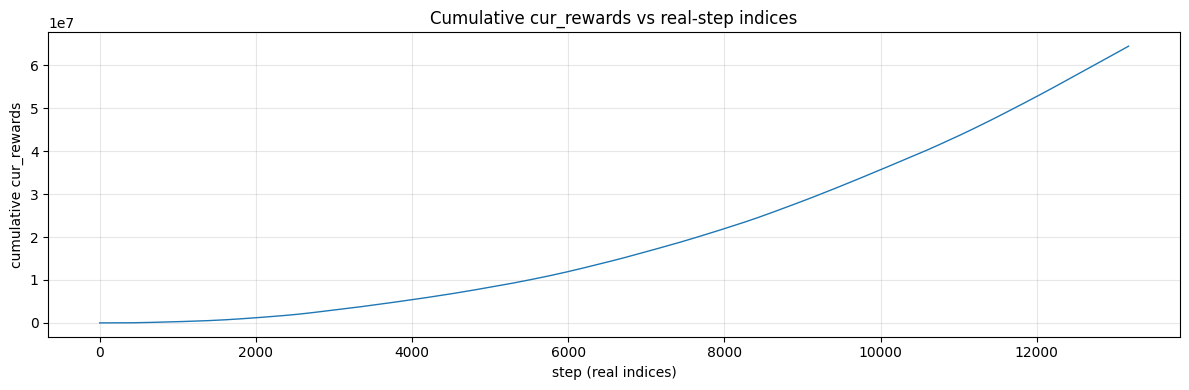

In [20]:
import numpy as np
import matplotlib.pyplot as plt

status = np.asarray(data["status"]).reshape(-1)
cur_rewards = np.asarray(data["env_return"])  # flatten 하지 않음

# step당 1개 y값 만들기
if cur_rewards.ndim == 1:
    y = cur_rewards
else:
    y = cur_rewards.reshape(cur_rewards.shape[0], -1)[:, 0]

# real step의 "원본 인덱스"
real_idx = np.where(status == 0)[0]

# x축: real indices, y축: 해당 cur_rewards
x = np.arange(len(real_idx))
y_plot = y[real_idx]

# 누적합으로 변경
y_cum = np.cumsum(y_plot)

plt.figure(figsize=(12, 4))
plt.plot(x, y_cum, linewidth=1)
plt.xlabel("step (real indices)")
plt.ylabel("cumulative cur_rewards")
plt.title("Cumulative cur_rewards vs real-step indices")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Found 4 files under test (subXXX only)
After filter: 4 files

== SUBJECT: sub001 ==

[delta_q]
  NOOP:    n=8710 mean=0.4599 std=0.9721
  NonNOOP: n=15879 mean=0.4934 std=0.9939
  Mann-Whitney U p=1.24e-13 (***)

[delta_v]
  NOOP:    n=8084 mean=0.0884 std=0.1024
  NonNOOP: n=14772 mean=0.0860 std=0.0963
  Mann-Whitney U p=0.439 (ns)

[H_all]
  NOOP:    n=8710 mean=1.4975 std=0.1513
  NonNOOP: n=15879 mean=1.4682 std=0.1376
  Mann-Whitney U p=6.67e-65 (***)

[p_noop]
  NOOP:    n=8710 mean=0.0980 std=0.0261
  NonNOOP: n=15879 mean=0.0932 std=0.0232
  Mann-Whitney U p=2e-38 (***)

[V_prev(cur_v)]
  NOOP:    n=8710 mean=2.2561 std=0.9431
  NonNOOP: n=15879 mean=2.3875 std=0.8640
  Mann-Whitney U p=2.88e-18 (***)

[vre]
  NOOP:    n=8706 mean=0.1229 std=0.8724
  NonNOOP: n=15879 mean=-0.1992 std=1.2572
  Mann-Whitney U p=2.56e-117 (***)

[vre_abs_q]
  NOOP:    n=8706 mean=0.2877 std=0.8327
  NonNOOP: n=15879 mean=0.6211 std=1.1110
  Mann-Whitney U p=6.18e-194 (***)

[vre_abs_v]
  NOOP:   

/tmp/ipykernel_547994/3799762440.py:350: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([a, b], labels=["NOOP", "Non-NOOP"], showfliers=False)
/tmp/ipykernel_547994/3799762440.py:350: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([a, b], labels=["NOOP", "Non-NOOP"], showfliers=False)
/tmp/ipykernel_547994/3799762440.py:350: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([a, b], labels=["NOOP", "Non-NOOP"], showfliers=False)
/tmp/ipykernel_547994/3799762440.py:350: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; suppor

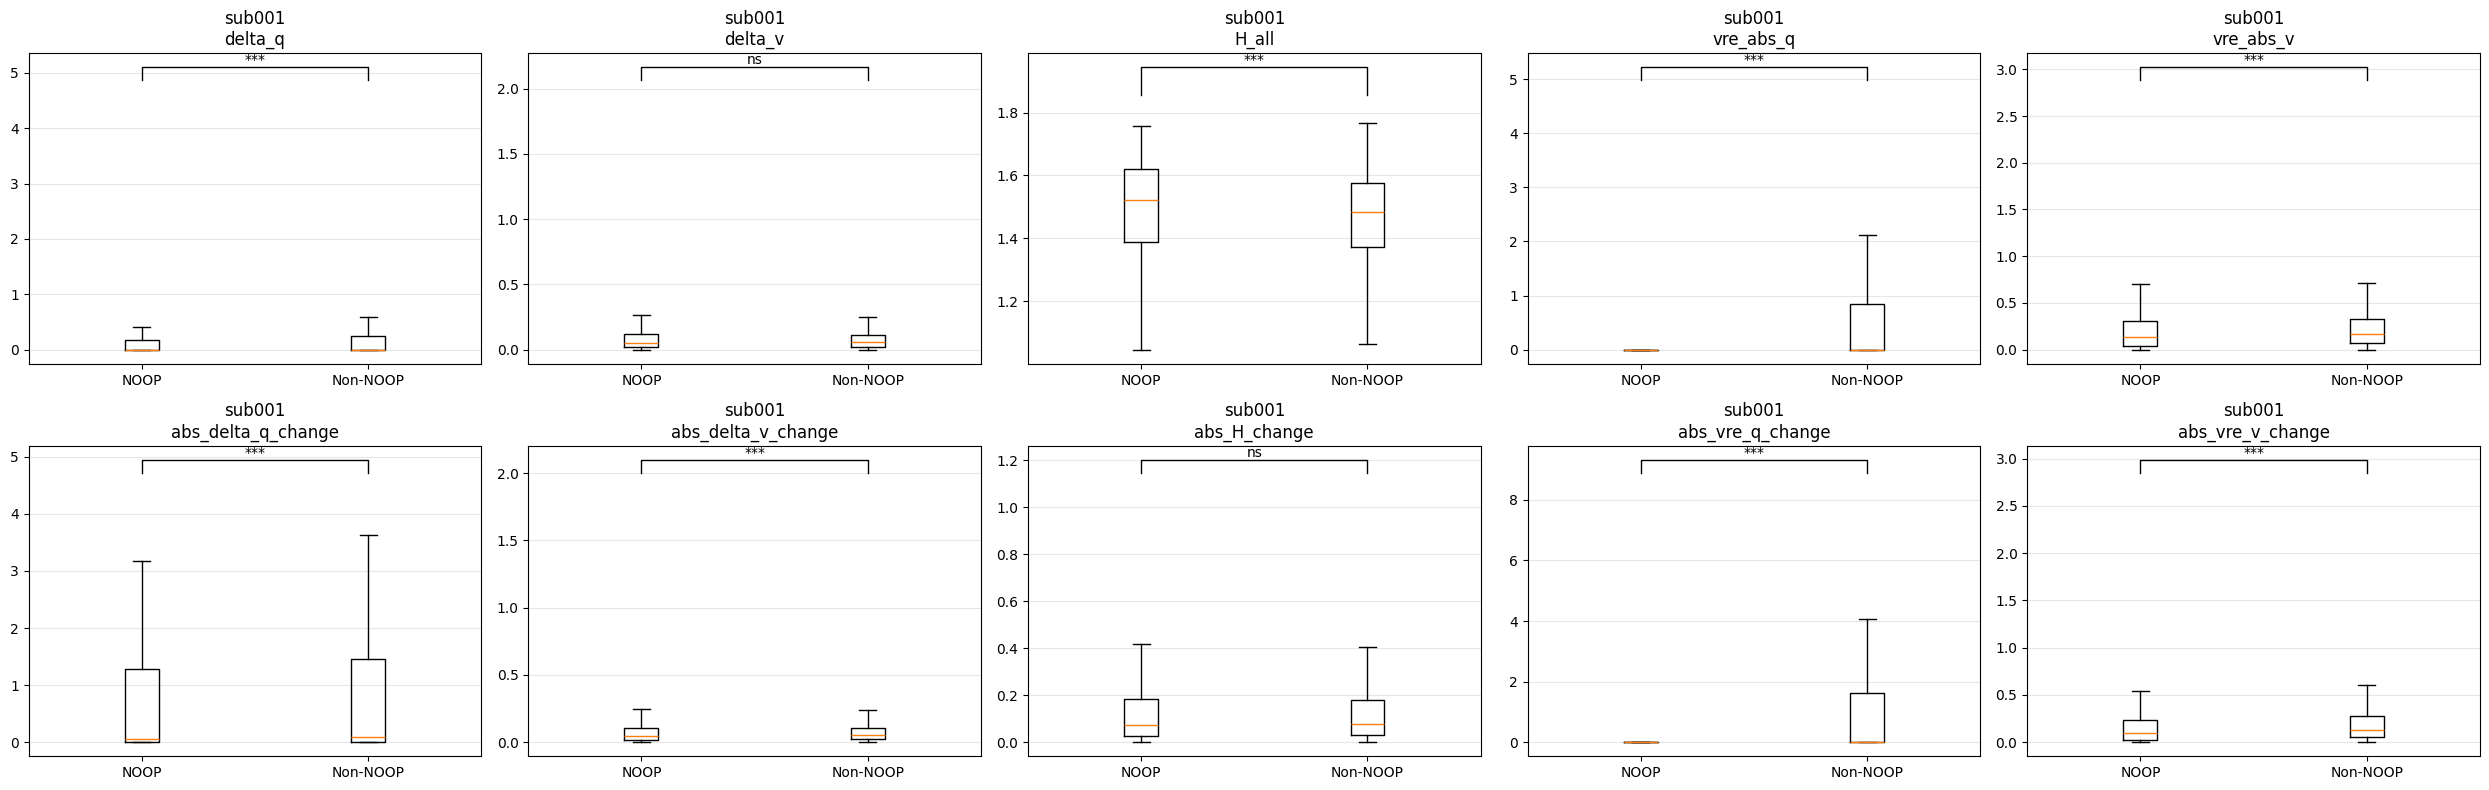

In [2]:
import re
from pathlib import Path
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# ====== 설정 ======
BASE_DIR = Path("./test")
FILE_GLOB = "*.npy"

# ---- 필터링 옵션 (None이면 전체 포함) ----
FILTER_SUB = "sub001"   # 예: "sub002"
FILTER_SES = "04"       # 예: "03" 또는 "3"
FILTER_BLOCK = None     # 예: "7"
FILTER_GAME = None      # 예: "2"
FILTER_SUFFIX = None    # 예: "000"

# 어떤 레벨을 출력할지 (True면 통계 출력 + 플롯 출력)
SHOW_FILE_LEVEL = False
SHOW_SESSION_BLOCK_LEVEL = False
SHOW_SESSION_LEVEL = False
SHOW_SUBJECT_LEVEL = True

# ====== 유틸 ======
def sig_label(p):
    if not np.isfinite(p):
        return "ns"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"

def top2_gap(mat):
    if mat.shape[1] < 2:
        return np.full(mat.shape[0], np.nan)
    part = np.partition(mat, -2, axis=1)[:, -2:]
    return part.max(axis=1) - part.min(axis=1)

def top2_gap_1d(vals):
    if len(vals) < 2:
        return np.nan
    part = np.partition(vals, -2)[-2:]
    return part.max() - part.min()

def parse_meta(path: Path):
    """
    path 예: test/sub002/ses-03/sub002-ses03-block7-game2_000.npy
    """
    sub = path.parts[-3] if len(path.parts) >= 3 else None  # sub002
    ses_folder = path.parts[-2] if len(path.parts) >= 2 else None  # ses-03

    base = path.stem  # sub002-ses03-block7-game2_000
    def grab(pattern):
        m = re.search(pattern, base)
        return m.group(1) if m else None

    sub_in = grab(r"(sub\d+)")
    ses_in = grab(r"ses(\d+)")
    block_in = grab(r"block(\d+)")
    game_in = grab(r"game(\d+)")
    suffix_in = grab(r"_(\d+)$")

    if not sub_in and sub and re.match(r"sub\d+", sub):
        sub_in = sub
    if not ses_in and ses_folder and re.match(r"ses-\d+", ses_folder):
        ses_in = ses_folder.replace("ses-", "")

    return {
        "sub": sub_in,          # "sub002"
        "ses": ses_in,          # "03"
        "block": block_in,      # "7"
        "game": game_in,        # "2"
        "suffix": suffix_in,    # "000"
        "file": str(path),
        "basename": path.name,
    }

def match_filter(val, flt):
    if flt is None:
        return True
    if val is None:
        return False
    return str(val).lstrip("0") == str(flt).lstrip("0")

def passes_filters(meta):
    return (
        (FILTER_SUB is None or meta["sub"] == FILTER_SUB)
        and match_filter(meta["ses"], FILTER_SES)
        and match_filter(meta["block"], FILTER_BLOCK)
        and match_filter(meta["game"], FILTER_GAME)
        and match_filter(meta["suffix"], FILTER_SUFFIX)
    )

def to_action_ids(x):
    if x is None:
        return None
    arr = np.asarray(x)
    if arr.ndim == 1:
        return arr.astype(int)
    return np.argmax(arr, axis=1)

def compute_metrics(data):
    tree = data["tree_reps"]

    q_key = "cur_qs_mean"
    v_key = "cur_v"
    root_q_key = "root_qs_mean"

    status = np.asarray(data["status"])

    # human_action / thinker_action 각각 분리
    human_action_raw = data.get("human_action", None)
    thinker_action_raw = data.get("thinker_action", None)

    human_action_ids = to_action_ids(human_action_raw)
    thinker_action_ids = to_action_ids(thinker_action_raw)

    # metrics 계산에 쓸 기본 action (human 우선, 없으면 thinker)
    if human_action_ids is not None:
        action_ids = human_action_ids
    elif thinker_action_ids is not None:
        action_ids = thinker_action_ids
    else:
        raise ValueError("No human_action or thinker_action found in data.")

    q_all = np.asarray(tree[q_key])
    v_all = np.asarray(tree[v_key]).reshape(-1)
    root_qs = np.asarray(tree[root_q_key]) if root_q_key in tree else None
    root_v_all = np.asarray(tree["root_v"]).reshape(-1) if "root_v" in tree else None

    actor_policy = np.asarray(data["actor_policy"]) if "actor_policy" in data else None
    if actor_policy is None:
        logits_all = None
    elif actor_policy.ndim >= 2:
        logits_all = actor_policy.reshape(actor_policy.shape[0], -1)
    else:
        logits_all = actor_policy

    num_actions = q_all.shape[1]

    real_all = np.where(status == 0)[0]
    imag2_indices = np.where(status == 2)[0]

    prev_imag_all = np.full(real_all.shape[0], -1, dtype=int)
    j = 0
    for i, r in enumerate(real_all):
        while j < len(imag2_indices) and imag2_indices[j] < r:
            j += 1
        prev_imag_all[i] = imag2_indices[j - 1] if j > 0 else -1

    pos_all = np.arange(len(real_all))
    pos_in_real = pos_all[1:]
    real_indices = real_all[pos_in_real]
    prev_imag = prev_imag_all[pos_in_real]

    valid = prev_imag >= 0
    pos_in_real = pos_in_real[valid]
    real_indices = real_indices[valid]
    prev_imag = prev_imag[valid]

    # decision-time 기준 action들
    real_actions = action_ids[real_indices]
    human_actions = human_action_ids[real_indices] if human_action_ids is not None else None
    thinker_actions = thinker_action_ids[real_indices] if thinker_action_ids is not None else None

    noop_mask = real_actions == 0
    nonnoop_mask = ~noop_mask

    Q_prev = q_all[prev_imag]
    V_prev = v_all[prev_imag]
    logits_prev = logits_all[prev_imag] if logits_all is not None else None

    delta_q = top2_gap(Q_prev)

    if "cur_action" in tree:
        cur_action = np.asarray(tree["cur_action"])
        if cur_action.ndim == 2 and cur_action.shape[1] == num_actions:
            cur_action_id = np.argmax(cur_action, axis=1)
        else:
            cur_action_id = cur_action.astype(int).reshape(-1)
    else:
        cur_action_id = None

    delta_v = np.full(len(pos_in_real), np.nan, dtype=float)
    vre_abs_v = np.full(len(pos_in_real), np.nan, dtype=float)

    if cur_action_id is not None:
        for i, pos in enumerate(pos_in_real):
            prev_real_idx = real_all[pos - 1]
            last_imag_idx = prev_imag[i]
            if last_imag_idx <= prev_real_idx:
                continue

            idx_range = np.arange(prev_real_idx + 1, last_imag_idx + 1)
            if len(idx_range) == 0:
                continue

            prev_status = status[idx_range - 1]
            mask = (status[idx_range] == 2) & ((prev_status == 0) | (prev_status == 1))
            sel_idx = idx_range[mask]
            if len(sel_idx) == 0:
                continue

            action_means = []
            action_mean_map = {}
            for a in range(num_actions):
                mask_a = cur_action_id[sel_idx] == a
                if np.any(mask_a):
                    mean_v = np.mean(v_all[sel_idx[mask_a]])
                    action_means.append(mean_v)
                    action_mean_map[a] = mean_v

            if len(action_means) >= 2:
                delta_v[i] = top2_gap_1d(np.array(action_means))

            if root_v_all is not None:
                ra = real_actions[i]
                if ra in action_mean_map:
                    vre_abs_v[i] = np.abs(action_mean_map[ra] - root_v_all[real_indices[i]])

    if logits_prev is not None:
        logits_shift = logits_prev - np.max(logits_prev, axis=1, keepdims=True)
        pi_prev = np.exp(logits_shift)
        pi_prev = pi_prev / np.sum(pi_prev, axis=1, keepdims=True)
        H_all = -np.nansum(pi_prev * np.log(pi_prev + 1e-12), axis=1)
        p_noop = pi_prev[:, 0]
    else:
        H_all = np.full(len(pos_in_real), np.nan, dtype=float)
        p_noop = np.full(len(pos_in_real), np.nan, dtype=float)

    next_real = np.full(pos_in_real.shape[0], -1, dtype=int)
    valid_next = (pos_in_real + 1) < len(real_all)
    next_real[valid_next] = real_all[pos_in_real[valid_next] + 1]

    vre = np.full(pos_in_real.shape[0], np.nan, dtype=float)
    if root_qs is not None:
        for i in range(len(pos_in_real)):
            nr = next_real[i]
            if nr >= 0:
                a = real_actions[i]
                vre[i] = Q_prev[i, a] - root_qs[nr, a]
    else:
        for i in range(len(pos_in_real)):
            nr = next_real[i]
            if nr >= 0:
                a = real_actions[i]
                vre[i] = Q_prev[i, a] - q_all[nr, a]

    vre_abs_q = np.abs(vre)

    metrics = {
        "delta_q": delta_q,
        "delta_v": delta_v,
        "H_all": H_all,
        "p_noop": p_noop,
        "V_prev(cur_v)": V_prev,
        "vre": vre,
        "vre_abs_q": vre_abs_q,
        "vre_abs_v": vre_abs_v,
    }

    # ---- 전후 변화(절댓값) ----
    n_real = len(real_all)
    delta_q_by_pos = np.full(n_real, np.nan)
    delta_v_by_pos = np.full(n_real, np.nan)
    H_by_pos = np.full(n_real, np.nan)
    vre_by_pos = np.full(n_real, np.nan)
    vre_v_by_pos = np.full(n_real, np.nan)

    delta_q_by_pos[pos_in_real] = delta_q
    delta_v_by_pos[pos_in_real] = delta_v
    H_by_pos[pos_in_real] = H_all
    vre_by_pos[pos_in_real] = vre
    vre_v_by_pos[pos_in_real] = vre_abs_v

    next_pos = pos_in_real + 1
    valid_diff = next_pos < n_real

    diff_delta_q = np.full(pos_in_real.shape[0], np.nan)
    diff_delta_v = np.full(pos_in_real.shape[0], np.nan)
    diff_H = np.full(pos_in_real.shape[0], np.nan)
    diff_vre_q = np.full(pos_in_real.shape[0], np.nan)
    diff_vre_v = np.full(pos_in_real.shape[0], np.nan)

    pos_valid = pos_in_real[valid_diff]
    next_valid = next_pos[valid_diff]

    mask_q = np.isfinite(delta_q_by_pos[pos_valid]) & np.isfinite(delta_q_by_pos[next_valid])
    mask_vv = np.isfinite(delta_v_by_pos[pos_valid]) & np.isfinite(delta_v_by_pos[next_valid])
    mask_H = np.isfinite(H_by_pos[pos_valid]) & np.isfinite(H_by_pos[next_valid])
    mask_vre_q = np.isfinite(vre_by_pos[pos_valid]) & np.isfinite(vre_by_pos[next_valid])
    mask_vre_v = np.isfinite(vre_v_by_pos[pos_valid]) & np.isfinite(vre_v_by_pos[next_valid])

    diff_delta_q[np.where(valid_diff)[0][mask_q]] = np.abs(
        delta_q_by_pos[pos_valid[mask_q]] - delta_q_by_pos[next_valid[mask_q]]
    )
    diff_delta_v[np.where(valid_diff)[0][mask_vv]] = np.abs(
        delta_v_by_pos[pos_valid[mask_vv]] - delta_v_by_pos[next_valid[mask_vv]]
    )
    diff_H[np.where(valid_diff)[0][mask_H]] = np.abs(
        H_by_pos[pos_valid[mask_H]] - H_by_pos[next_valid[mask_H]]
    )
    diff_vre_q[np.where(valid_diff)[0][mask_vre_q]] = np.abs(
        vre_by_pos[pos_valid[mask_vre_q]] - vre_by_pos[next_valid[mask_vre_q]]
    )
    diff_vre_v[np.where(valid_diff)[0][mask_vre_v]] = np.abs(
        vre_v_by_pos[pos_valid[mask_vre_v]] - vre_v_by_pos[next_valid[mask_vre_v]]
    )

    metrics.update({
        "abs_delta_q_change": diff_delta_q,
        "abs_delta_v_change": diff_delta_v,
        "abs_H_change": diff_H,
        "abs_vre_q_change": diff_vre_q,
        "abs_vre_v_change": diff_vre_v,
    })

    return metrics, noop_mask, nonnoop_mask, human_actions, thinker_actions

def summarize_arrays(name, a, b):
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    print(f"\n[{name}]")
    print(f"  NOOP:    n={len(a)} mean={np.mean(a):.4f} std={np.std(a):.4f}")
    print(f"  NonNOOP: n={len(b)} mean={np.mean(b):.4f} std={np.std(b):.4f}")
    p = np.nan
    if len(a) > 1 and len(b) > 1:
        _, p = stats.mannwhitneyu(a, b, alternative="two-sided")
        print(f"  Mann-Whitney U p={p:.3g} ({sig_label(p)})")
    return p

def boxplot_metrics(group_name, metrics_store, pvals_store):
    plot_names = [
        "delta_q", "delta_v", "H_all", "vre_abs_q", "vre_abs_v",
        "abs_delta_q_change", "abs_delta_v_change", "abs_H_change",
        "abs_vre_q_change", "abs_vre_v_change",
    ]
    fig, axes = plt.subplots(2, 5, figsize=(5 * 5, 4 * 2))
    axes = axes.flatten()

    for ax, name in zip(axes, plot_names):
        if name not in metrics_store:
            ax.axis("off")
            continue
        a = metrics_store[name]["noop"]
        b = metrics_store[name]["nonnoop"]
        ax.boxplot([a, b], labels=["NOOP", "Non-NOOP"], showfliers=False)
        ax.set_title(f"{group_name}\n{name}")
        ax.grid(axis="y", alpha=0.3)

        p = pvals_store.get(name, np.nan)
        sig = sig_label(p)
        if len(a) > 0 and len(b) > 0 and np.isfinite(p):
            y_max = np.nanmax(np.concatenate([a, b]))
            y = y_max + (0.05 * y_max if y_max != 0 else 0.05)
            h = (0.05 * y_max if y_max != 0 else 0.05)
            ax.plot([1, 1, 2, 2], [y, y + h, y + h, y], lw=1.0, c="black")
            ax.text(1.5, y + h, sig, ha="center", va="bottom")

    plt.tight_layout()
    plt.show()

# ====== 파일 로드 (subXXX 폴더만 스캔) ======
sub_dirs = [
    d for d in BASE_DIR.iterdir()
    if d.is_dir() and re.fullmatch(r"sub\d+", d.name)
]

files = []
for sd in sub_dirs:
    files.extend(sd.rglob(FILE_GLOB))

files = sorted(files)
print(f"Found {len(files)} files under {BASE_DIR} (subXXX only)")

records = []
for f in files:
    meta = parse_meta(f)
    if not passes_filters(meta):
        continue
    data = np.load(f, allow_pickle=True).item()
    metrics, noop_mask, nonnoop_mask, human_actions, thinker_actions = compute_metrics(data)
    records.append({
        "path": f,
        "meta": meta,
        "metrics": metrics,
        "noop_mask": noop_mask,
        "nonnoop_mask": nonnoop_mask,
        "human_action": human_actions,     # decision-time aligned
        "thinker_action": thinker_actions, # decision-time aligned
    })

print(f"After filter: {len(records)} files")

# ====== 그룹 집계 ======
def init_group_store():
    return {}

def add_to_group(store, group_key, metrics, noop_mask, nonnoop_mask):
    if group_key not in store:
        store[group_key] = {}
    for name, arr in metrics.items():
        if name not in store[group_key]:
            store[group_key][name] = {"noop": [], "nonnoop": []}
        store[group_key][name]["noop"].append(arr[noop_mask & np.isfinite(arr)])
        store[group_key][name]["nonnoop"].append(arr[nonnoop_mask & np.isfinite(arr)])

def finalize_group(store):
    out = {}
    for g, md in store.items():
        out[g] = {}
        for name, parts in md.items():
            a = np.concatenate(parts["noop"]) if len(parts["noop"]) else np.array([])
            b = np.concatenate(parts["nonnoop"]) if len(parts["nonnoop"]) else np.array([])
            out[g][name] = {"noop": a, "nonnoop": b}
    return out

file_store = init_group_store()
sess_block_store = init_group_store()
sess_store = init_group_store()
sub_store = init_group_store()

for r in records:
    m = r["meta"]
    metrics = r["metrics"]
    noop_mask = r["noop_mask"]
    nonnoop_mask = r["nonnoop_mask"]

    file_key = m["basename"]
    sb_key = f"{m['sub']}_ses{m['ses']}_block{m['block']}"
    s_key = f"{m['sub']}_ses{m['ses']}"
    sub_key = f"{m['sub']}"

    add_to_group(file_store, file_key, metrics, noop_mask, nonnoop_mask)
    add_to_group(sess_block_store, sb_key, metrics, noop_mask, nonnoop_mask)
    add_to_group(sess_store, s_key, metrics, noop_mask, nonnoop_mask)
    add_to_group(sub_store, sub_key, metrics, noop_mask, nonnoop_mask)

file_store = finalize_group(file_store)
sess_block_store = finalize_group(sess_block_store)
sess_store = finalize_group(sess_store)
sub_store = finalize_group(sub_store)

# ====== 출력 ======
if SHOW_FILE_LEVEL:
    for g, metrics_store in file_store.items():
        print(f"\n== FILE: {g} ==")
        pvals = {}
        for name, arrs in metrics_store.items():
            pvals[name] = summarize_arrays(name, arrs["noop"], arrs["nonnoop"])
        boxplot_metrics(g, metrics_store, pvals)

if SHOW_SESSION_BLOCK_LEVEL:
    for g, metrics_store in sess_block_store.items():
        print(f"\n== SES-BLOCK: {g} ==")
        pvals = {}
        for name, arrs in metrics_store.items():
            pvals[name] = summarize_arrays(name, arrs["noop"], arrs["nonnoop"])
        boxplot_metrics(g, metrics_store, pvals)

if SHOW_SESSION_LEVEL:
    for g, metrics_store in sess_store.items():
        print(f"\n== SESSION: {g} ==")
        pvals = {}
        for name, arrs in metrics_store.items():
            pvals[name] = summarize_arrays(name, arrs["noop"], arrs["nonnoop"])
        boxplot_metrics(g, metrics_store, pvals)

if SHOW_SUBJECT_LEVEL:
    for g, metrics_store in sub_store.items():
        print(f"\n== SUBJECT: {g} ==")
        pvals = {}
        for name, arrs in metrics_store.items():
            pvals[name] = summarize_arrays(name, arrs["noop"], arrs["nonnoop"])
        boxplot_metrics(g, metrics_store, pvals)


Found 4 files under test (subXXX only)
Discovered file list:
 01. test/sub001/ses-04/sub001-ses04-block2-game2_000.npy
 02. test/sub001/ses-04/sub001-ses04-block2-game2_001.npy
 03. test/sub001/ses-04/sub001-ses04-block2-game2_002.npy
 04. test/sub001/ses-04/sub001-ses04-block2-game2_003.npy

Files passing filters (sub/ses/block/game/suffix): 4
 01. test/sub001/ses-04/sub001-ses04-block2-game2_000.npy
 02. test/sub001/ses-04/sub001-ses04-block2-game2_001.npy
 03. test/sub001/ses-04/sub001-ses04-block2-game2_002.npy
 04. test/sub001/ses-04/sub001-ses04-block2-game2_003.npy

Files used for analysis: 4
 01. test/sub001/ses-04/sub001-ses04-block2-game2_000.npy (samples=3917)
 02. test/sub001/ses-04/sub001-ses04-block2-game2_001.npy (samples=4157)
 03. test/sub001/ses-04/sub001-ses04-block2-game2_002.npy (samples=10719)
 04. test/sub001/ses-04/sub001-ses04-block2-game2_003.npy (samples=5796)
Kept keys (25): ['root_action', 'root_r', 'root_d', 'root_v', 'root_policy', 'root_qs_mean', 'root_q

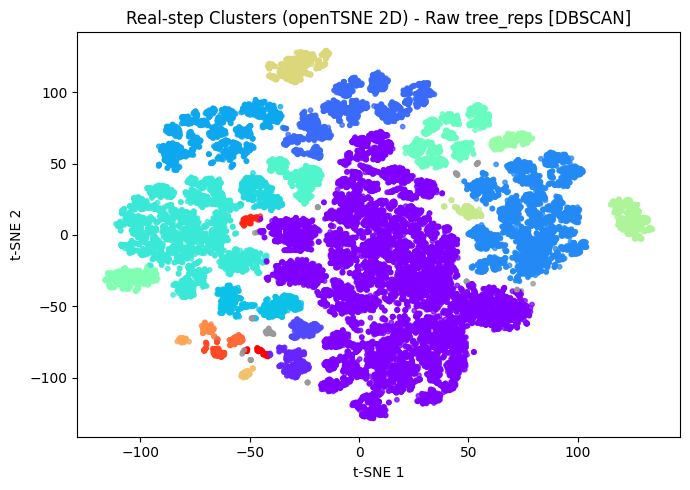

/tmp/ipykernel_547994/3506345542.py:857: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(group_data, labels=group_names, showfliers=False)



[delta_q] pairwise MWU (fdr_bh, alpha=0.05)
 - C0 vs C1: p_raw=2.213e-01, p_adj=2.872e-01, ns ns
 - C0 vs C2: p_raw=8.159e-01, p_adj=8.495e-01, ns ns
 - C0 vs C3: p_raw=1.954e-25, p_adj=1.301e-24, sig ****
 - C0 vs C4: p_raw=4.514e-11, p_adj=1.241e-10, sig ****
 - C0 vs C5: p_raw=2.957e-16, p_adj=9.591e-16, sig ****
 - C0 vs C6: p_raw=1.283e-04, p_adj=2.422e-04, sig ***
 - C0 vs C7: p_raw=8.457e-23, p_adj=4.462e-22, sig ****
 - C0 vs C8: p_raw=2.496e-30, p_adj=1.914e-29, sig ****
 - C0 vs C9: p_raw=7.910e-19, p_adj=2.900e-18, sig ****
 - C0 vs C10: p_raw=2.479e-09, p_adj=6.150e-09, sig ****
 - C0 vs C11: p_raw=7.747e-08, p_adj=1.750e-07, sig ****
 - C0 vs C12: p_raw=3.005e-06, p_adj=6.388e-06, sig ****
 - C0 vs C13: p_raw=1.367e-03, p_adj=2.352e-03, sig **
 - C0 vs C14: p_raw=7.377e-03, p_adj=1.174e-02, sig *
 - C0 vs C15: p_raw=6.209e-08, p_adj=1.433e-07, sig ****
 - C0 vs C16: p_raw=3.137e-19, p_adj=1.185e-18, sig ****
 - C0 vs C17: p_raw=5.925e-18, p_adj=1.999e-17, sig ****
 - C0 v

/tmp/ipykernel_547994/3506345542.py:857: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(group_data, labels=group_names, showfliers=False)



[delta_v] pairwise MWU (fdr_bh, alpha=0.05)
 - C0 vs C1: p_raw=9.335e-02, p_adj=2.036e-01, ns ns
 - C0 vs C2: p_raw=7.735e-01, p_adj=8.855e-01, ns ns
 - C0 vs C3: p_raw=5.791e-01, p_adj=7.475e-01, ns ns
 - C0 vs C4: p_raw=3.888e-01, p_adj=6.042e-01, ns ns
 - C0 vs C5: p_raw=1.560e-01, p_adj=3.083e-01, ns ns
 - C0 vs C6: p_raw=8.813e-01, p_adj=9.342e-01, ns ns
 - C0 vs C7: p_raw=2.636e-01, p_adj=4.630e-01, ns ns
 - C0 vs C8: p_raw=4.303e-01, p_adj=6.366e-01, ns ns
 - C0 vs C9: p_raw=6.042e-01, p_adj=7.754e-01, ns ns
 - C0 vs C10: p_raw=2.360e-01, p_adj=4.234e-01, ns ns
 - C0 vs C11: p_raw=9.057e-01, p_adj=9.429e-01, ns ns
 - C0 vs C12: p_raw=5.364e-01, p_adj=7.219e-01, ns ns
 - C0 vs C13: p_raw=8.972e-01, p_adj=9.419e-01, ns ns
 - C0 vs C14: p_raw=3.964e-01, p_adj=6.042e-01, ns ns
 - C0 vs C15: p_raw=1.143e-01, p_adj=2.429e-01, ns ns
 - C0 vs C16: p_raw=8.153e-17, p_adj=6.446e-16, sig ****
 - C0 vs C17: p_raw=1.570e-16, p_adj=1.135e-15, sig ****
 - C0 vs C18: p_raw=2.238e-19, p_adj=2.2

/tmp/ipykernel_547994/3506345542.py:857: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(group_data, labels=group_names, showfliers=False)


...


[vre_abs_v] pairwise MWU (fdr_bh, alpha=0.05)
 - C0 vs C1: p_raw=6.649e-01, p_adj=7.543e-01, ns ns
 - C0 vs C2: p_raw=5.587e-01, p_adj=6.575e-01, ns ns
 - C0 vs C3: p_raw=9.716e-01, p_adj=9.755e-01, ns ns
 - C0 vs C4: p_raw=1.508e-07, p_adj=3.973e-07, sig ****
 - C0 vs C5: p_raw=2.886e-01, p_adj=3.842e-01, ns ns
 - C0 vs C6: p_raw=4.752e-01, p_adj=5.809e-01, ns ns
 - C0 vs C7: p_raw=3.306e-01, p_adj=4.334e-01, ns ns
 - C0 vs C8: p_raw=6.438e-05, p_adj=1.581e-04, sig ***
 - C0 vs C9: p_raw=2.529e-03, p_adj=5.333e-03, sig **
 - C0 vs C10: p_raw=1.631e-01, p_adj=2.345e-01, ns ns
 - C0 vs C11: p_raw=6.092e-03, p_adj=1.223e-02, sig *
 - C0 vs C12: p_raw=8.292e-02, p_adj=1.279e-01, ns ns
 - C0 vs C13: p_raw=5.665e-02, p_adj=9.430e-02, ns ns
 - C0 vs C14: p_raw=2.283e-01, p_adj=3.173e-01, ns ns
 - C0 vs C15: p_raw=2.124e-02, p_adj=3.980e-02, sig *
 - C0 vs C16: p_raw=4.609e-15, p_adj=2.776e-14, sig ****
 - C0 vs C17: p_raw=2.492e-13, p_adj=1.126e-12, sig ****
 - C0 vs C18: p_raw=6.250e-20, p

/tmp/ipykernel_547994/3506345542.py:857: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(group_data, labels=group_names, showfliers=False)



[H_all] pairwise MWU (fdr_bh, alpha=0.05)
 - C0 vs C1: p_raw=1.525e-02, p_adj=1.795e-02, sig *
 - C0 vs C2: p_raw=7.157e-01, p_adj=7.301e-01, ns ns
 - C0 vs C3: p_raw=4.359e-295, p_adj=5.514e-293, sig ****
 - C0 vs C4: p_raw=2.675e-29, p_adj=5.735e-29, sig ****
 - C0 vs C5: p_raw=8.799e-304, p_adj=2.226e-301, sig ****
 - C0 vs C6: p_raw=1.445e-16, p_adj=2.299e-16, sig ****
 - C0 vs C7: p_raw=4.658e-70, p_adj=9.065e-69, sig ****
 - C0 vs C8: p_raw=5.368e-40, p_adj=1.913e-39, sig ****
 - C0 vs C9: p_raw=6.544e-98, p_adj=1.656e-96, sig ****
 - C0 vs C10: p_raw=1.915e-258, p_adj=1.615e-256, sig ****
 - C0 vs C11: p_raw=2.113e-10, p_adj=3.004e-10, sig ****
 - C0 vs C12: p_raw=1.486e-59, p_adj=1.567e-58, sig ****
 - C0 vs C13: p_raw=2.331e-16, p_adj=3.686e-16, sig ****
 - C0 vs C14: p_raw=1.320e-16, p_adj=2.114e-16, sig ****
 - C0 vs C15: p_raw=5.326e-36, p_adj=1.531e-35, sig ****
 - C0 vs C16: p_raw=9.348e-33, p_adj=2.253e-32, sig ****
 - C0 vs C17: p_raw=1.261e-27, p_adj=2.492e-27, sig **

/tmp/ipykernel_547994/3506345542.py:857: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(group_data, labels=group_names, showfliers=False)



[p_noop] pairwise MWU (fdr_bh, alpha=0.05)
 - C0 vs C1: p_raw=4.892e-01, p_adj=5.404e-01, ns ns
 - C0 vs C2: p_raw=5.244e-01, p_adj=5.768e-01, ns ns
 - C0 vs C3: p_raw=5.976e-250, p_adj=7.560e-248, sig ****
 - C0 vs C4: p_raw=6.615e-01, p_adj=6.973e-01, ns ns
 - C0 vs C5: p_raw=2.915e-258, p_adj=7.374e-256, sig ****
 - C0 vs C6: p_raw=6.484e-21, p_adj=1.745e-20, sig ****
 - C0 vs C7: p_raw=9.912e-76, p_adj=2.280e-74, sig ****
 - C0 vs C8: p_raw=1.116e-69, p_adj=2.173e-68, sig ****
 - C0 vs C9: p_raw=7.560e-95, p_adj=2.732e-93, sig ****
 - C0 vs C10: p_raw=5.186e-172, p_adj=2.624e-170, sig ****
 - C0 vs C11: p_raw=5.235e-12, p_adj=9.668e-12, sig ****
 - C0 vs C12: p_raw=6.675e-47, p_adj=9.382e-46, sig ****
 - C0 vs C13: p_raw=3.603e-13, p_adj=6.958e-13, sig ****
 - C0 vs C14: p_raw=8.150e-12, p_adj=1.483e-11, sig ****
 - C0 vs C15: p_raw=2.048e-55, p_adj=3.454e-54, sig ****
 - C0 vs C16: p_raw=4.727e-16, p_adj=1.013e-15, sig ****
 - C0 vs C17: p_raw=1.073e-08, p_adj=1.697e-08, sig ****

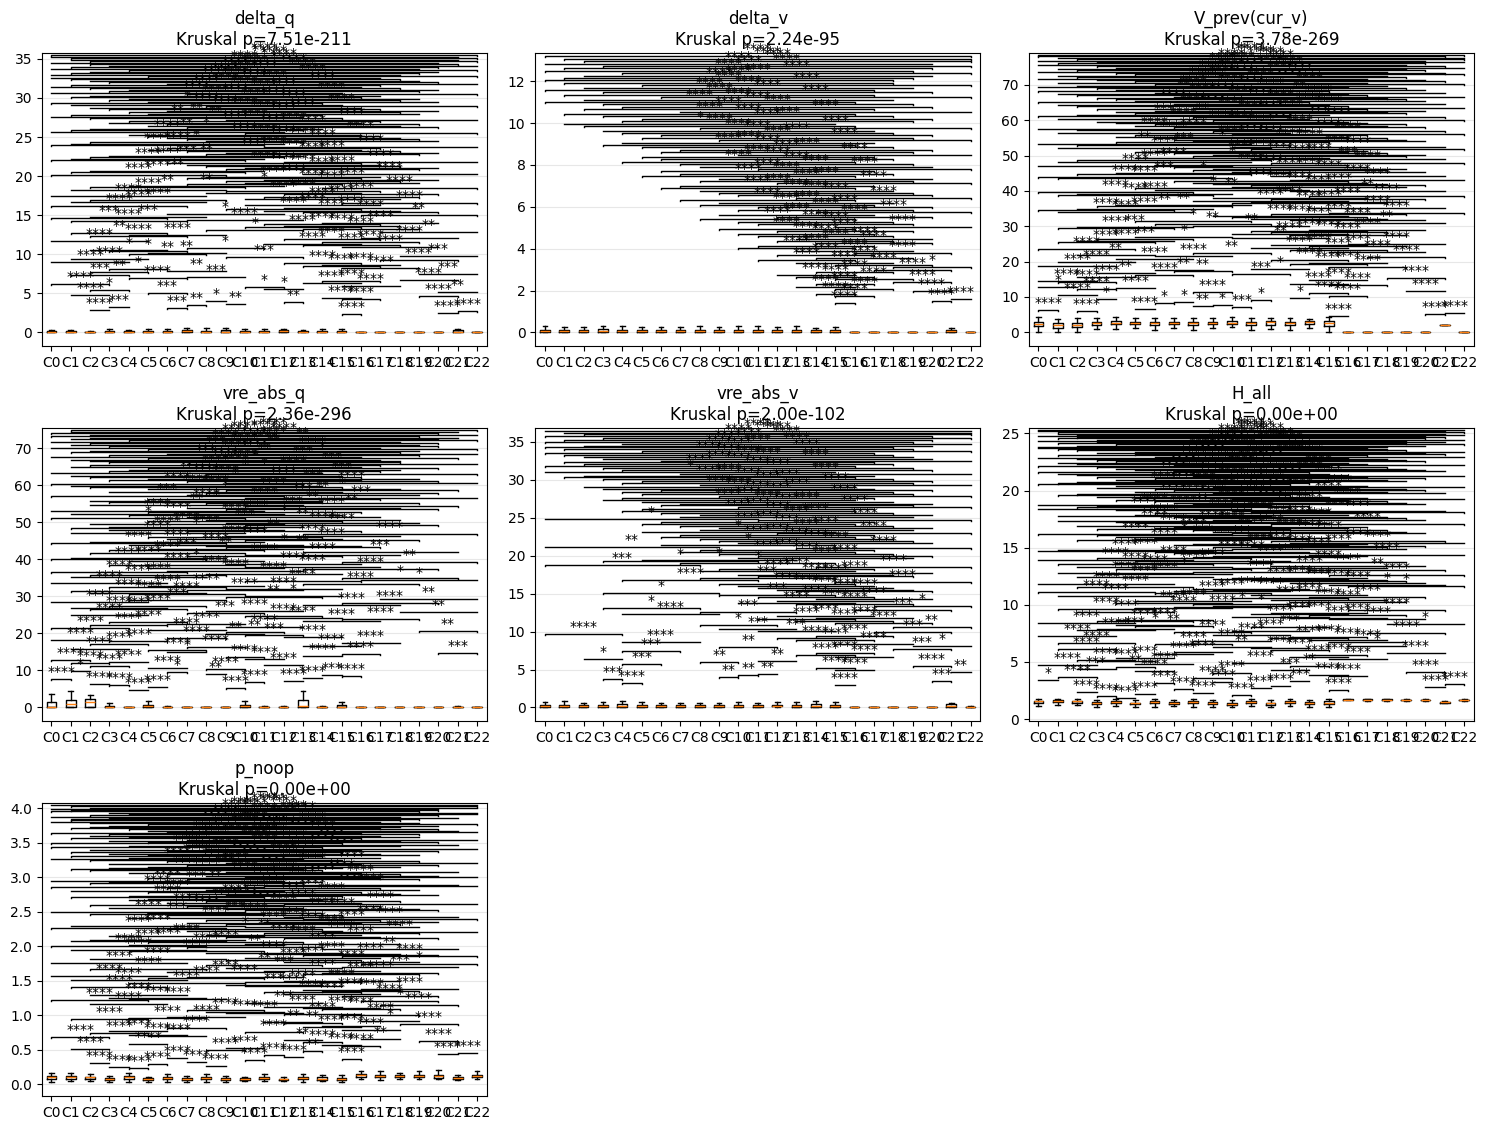


[CLUSTER 0] usable rows=3464 cols=6
                              BetaModel Results                               
Dep. Variable:                      y   Log-Likelihood:                 9668.8
Model:                      BetaModel   AIC:                        -1.932e+04
Method:            Maximum Likelihood   BIC:                        -1.927e+04
Date:                Mon, 09 Mar 2026                                         
Time:                        11:03:54                                         
No. Observations:                3464                                         
Df Residuals:                    3456                                         
Df Model:                           6                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -2.2052      0.003   -764.724      0.000      -2.211      -2.200
delta_

,coef,p
const,-2.205225,0.000000e+00
H_all,0.237630,0.000000e+00
V_prev(cur_v),0.067101,3.719950e-99
vre_abs_q,0.008013,6.054843e-03
vre_abs_v,0.004006,1.684916e-01
delta_v,0.002955,3.044532e-01
delta_q,0.002729,4.078330e-01


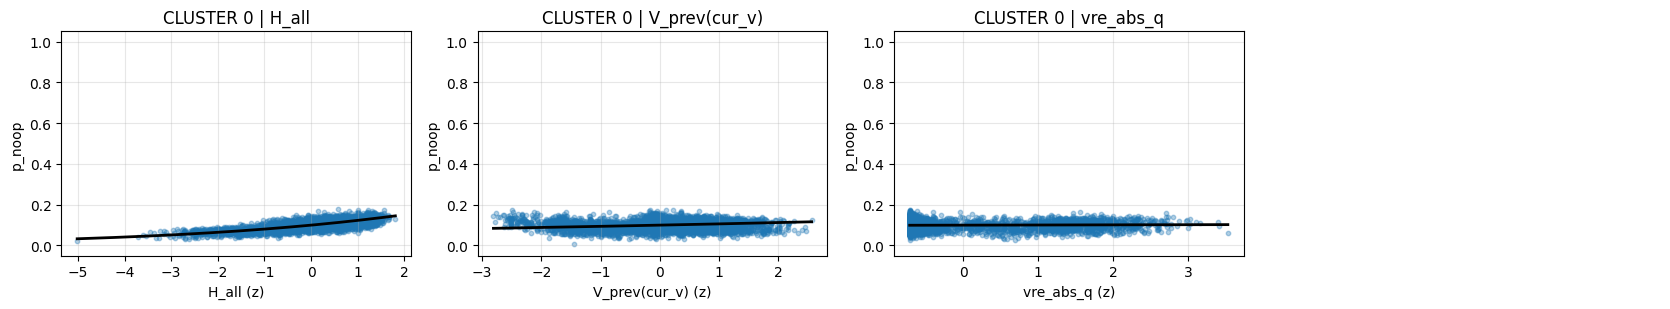


[CLUSTER 1] usable rows=139 cols=6
                              BetaModel Results                               
Dep. Variable:                      y   Log-Likelihood:                 391.23
Model:                      BetaModel   AIC:                            -766.5
Method:            Maximum Likelihood   BIC:                            -743.0
Date:                Mon, 09 Mar 2026                                         
Time:                        11:03:55                                         
No. Observations:                 139                                         
Df Residuals:                     131                                         
Df Model:                           6                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -2.2313      0.014   -155.300      0.000      -2.259      -2.203
delta_q

,coef,p
const,-2.231307,0.000000e+00
H_all,0.269480,1.431739e-54
V_prev(cur_v),0.057664,3.768884e-03
delta_v,-0.024675,1.143702e-01
delta_q,0.013523,4.389872e-01
vre_abs_q,0.008659,6.491192e-01
vre_abs_v,0.004403,7.694363e-01


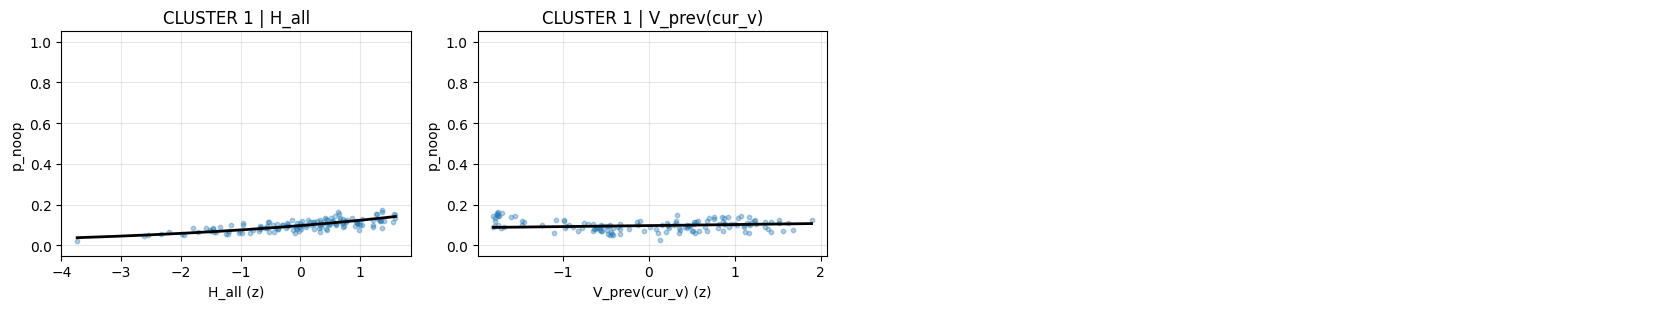


[CLUSTER 2] usable rows=87 cols=6
                              BetaModel Results                               
Dep. Variable:                      y   Log-Likelihood:                 255.07
Model:                      BetaModel   AIC:                            -494.1
Method:            Maximum Likelihood   BIC:                            -474.4
Date:                Mon, 09 Mar 2026                                         
Time:                        11:03:55                                         
No. Observations:                  87                                         
Df Residuals:                      79                                         
Df Model:                           6                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -2.2118      0.016   -140.434      0.000      -2.243      -2.181
delta_q 

,coef,p
const,-2.211751,0.000000e+00
H_all,0.201039,1.693819e-21
V_prev(cur_v),0.058652,1.645159e-03
delta_v,-0.021122,2.276877e-01
vre_abs_q,-0.012229,5.209733e-01
delta_q,0.003665,8.435163e-01
vre_abs_v,0.001110,9.471532e-01


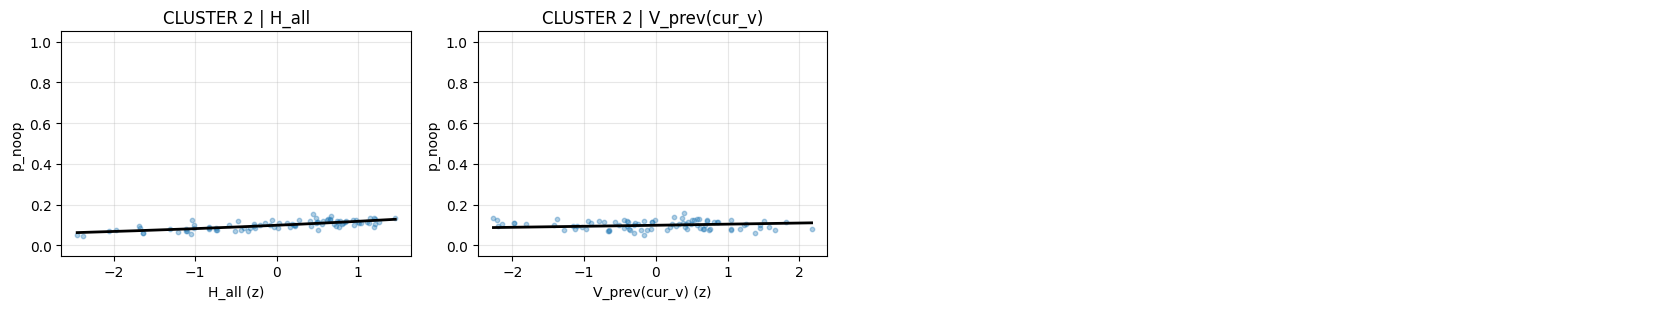


[CLUSTER 3] usable rows=672 cols=6
                              BetaModel Results                               
Dep. Variable:                      y   Log-Likelihood:                 2059.9
Model:                      BetaModel   AIC:                            -4104.
Method:            Maximum Likelihood   BIC:                            -4068.
Date:                Mon, 09 Mar 2026                                         
Time:                        11:03:55                                         
No. Observations:                 672                                         
Df Residuals:                     664                                         
Df Model:                           6                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -2.4591      0.006   -405.306      0.000      -2.471      -2.447
delta_q

,coef,p
const,-2.459059,0.000000e+00
H_all,0.157161,2.242621e-134
V_prev(cur_v),0.025932,2.622880e-05
vre_abs_q,0.006111,3.192736e-01
delta_q,-0.004767,4.504176e-01
vre_abs_v,0.004119,4.991925e-01
delta_v,-0.000526,9.323210e-01


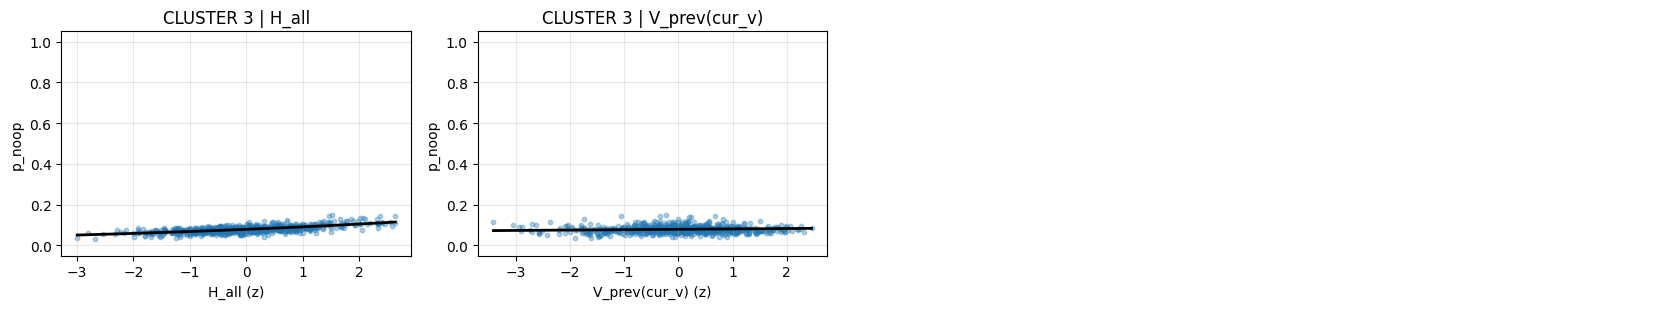


[CLUSTER 4] usable rows=830 cols=6
                              BetaModel Results                               
Dep. Variable:                      y   Log-Likelihood:                 2376.9
Model:                      BetaModel   AIC:                            -4738.
Method:            Maximum Likelihood   BIC:                            -4700.
Date:                Mon, 09 Mar 2026                                         
Time:                        11:03:56                                         
No. Observations:                 830                                         
Df Residuals:                     822                                         
Df Model:                           6                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -2.2128      0.006   -400.981      0.000      -2.224      -2.202
delta_q

,coef,p
const,-2.212767,0.000000e+00
H_all,0.196510,3.362608e-254
V_prev(cur_v),0.054148,1.029381e-21
vre_abs_v,-0.015521,5.373166e-03
delta_v,0.011163,4.558603e-02
vre_abs_q,-0.005595,3.027980e-01
delta_q,0.000767,9.001128e-01


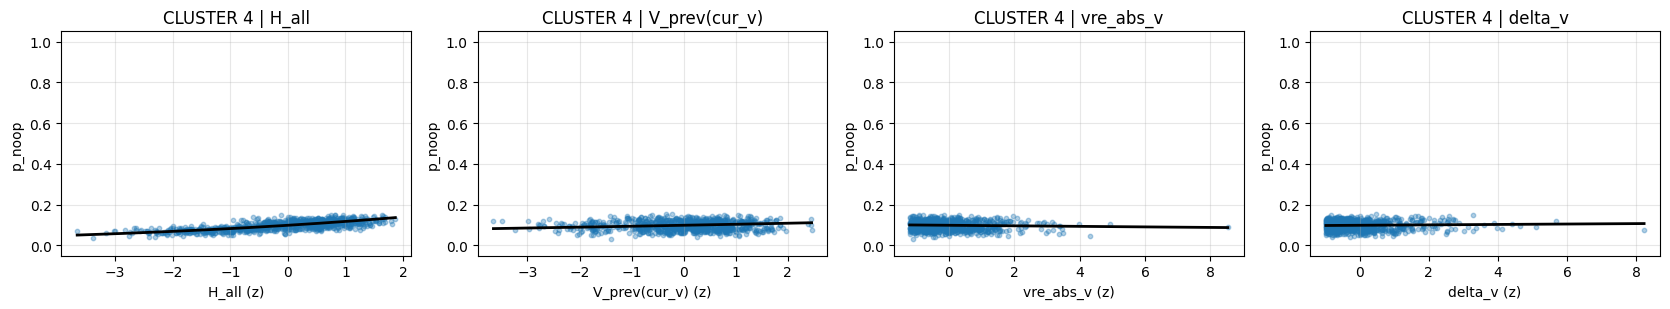


[CLUSTER 5] usable rows=681 cols=6
                              BetaModel Results                               
Dep. Variable:                      y   Log-Likelihood:                 2121.3
Model:                      BetaModel   AIC:                            -4227.
Method:            Maximum Likelihood   BIC:                            -4190.
Date:                Mon, 09 Mar 2026                                         
Time:                        11:03:56                                         
No. Observations:                 681                                         
Df Residuals:                     673                                         
Df Model:                           6                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -2.4635      0.006   -428.230      0.000      -2.475      -2.452
delta_q

,coef,p
const,-2.463492,0.000000e+00
H_all,0.149847,1.557636e-142
V_prev(cur_v),0.030070,6.929634e-07
vre_abs_v,-0.013141,2.259488e-02
delta_q,0.007681,1.924300e-01
delta_v,0.003360,5.610284e-01
vre_abs_q,0.001978,7.364893e-01


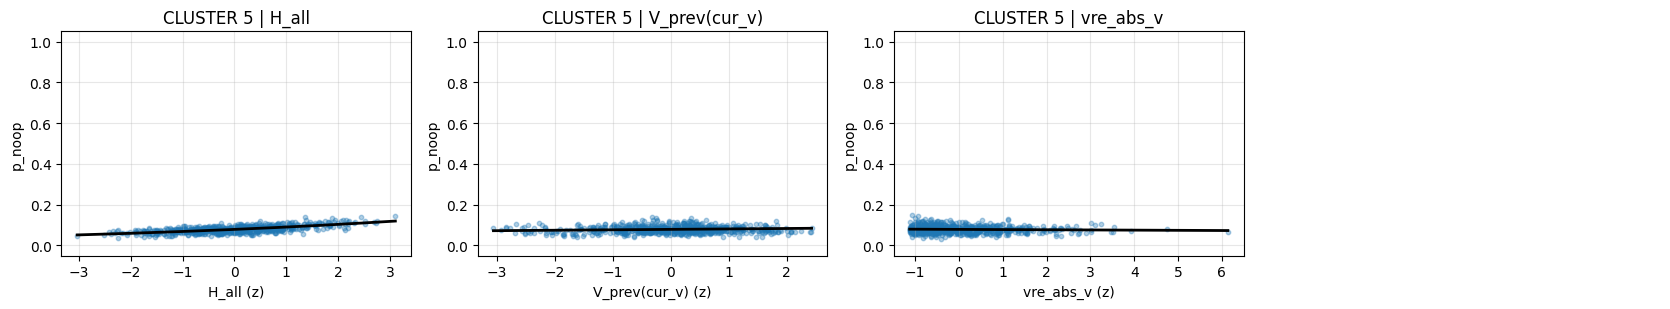


[CLUSTER 6] usable rows=263 cols=6
                              BetaModel Results                               
Dep. Variable:                      y   Log-Likelihood:                 772.76
Model:                      BetaModel   AIC:                            -1530.
Method:            Maximum Likelihood   BIC:                            -1501.
Date:                Mon, 09 Mar 2026                                         
Time:                        11:03:57                                         
No. Observations:                 263                                         
Df Residuals:                     255                                         
Df Model:                           6                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -2.3004      0.010   -235.642      0.000      -2.320      -2.281
delta_q

,coef,p
const,-2.300379,0.000000e+00
H_all,0.234180,1.390749e-102
V_prev(cur_v),0.059595,7.491078e-09
delta_v,-0.006993,4.906874e-01
vre_abs_v,0.006297,5.392331e-01
delta_q,-0.002169,8.341415e-01
vre_abs_q,-0.001551,8.733118e-01


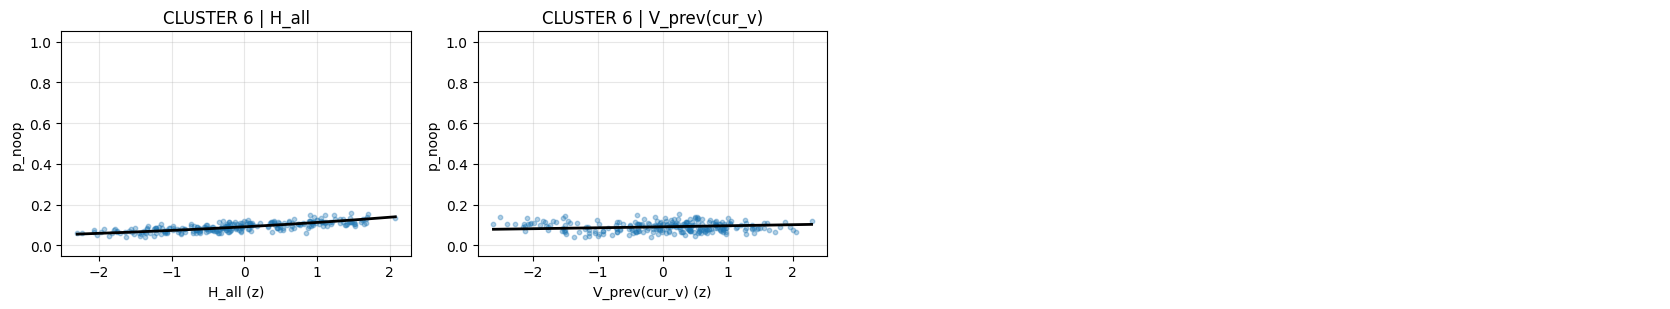


[CLUSTER 7] usable rows=276 cols=6
                              BetaModel Results                               
Dep. Variable:                      y   Log-Likelihood:                 860.04
Model:                      BetaModel   AIC:                            -1704.
Method:            Maximum Likelihood   BIC:                            -1675.
Date:                Mon, 09 Mar 2026                                         
Time:                        11:03:57                                         
No. Observations:                 276                                         
Df Residuals:                     268                                         
Df Model:                           6                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -2.4534      0.009   -273.726      0.000      -2.471      -2.436
delta_q

,coef,p
const,-2.453443,0.000000e+00
H_all,0.163708,5.877678e-69
V_prev(cur_v),0.046446,3.589732e-07
vre_abs_q,0.012530,1.519621e-01
delta_q,0.004427,6.160606e-01
vre_abs_v,-0.004347,6.286822e-01
delta_v,0.002506,7.802173e-01


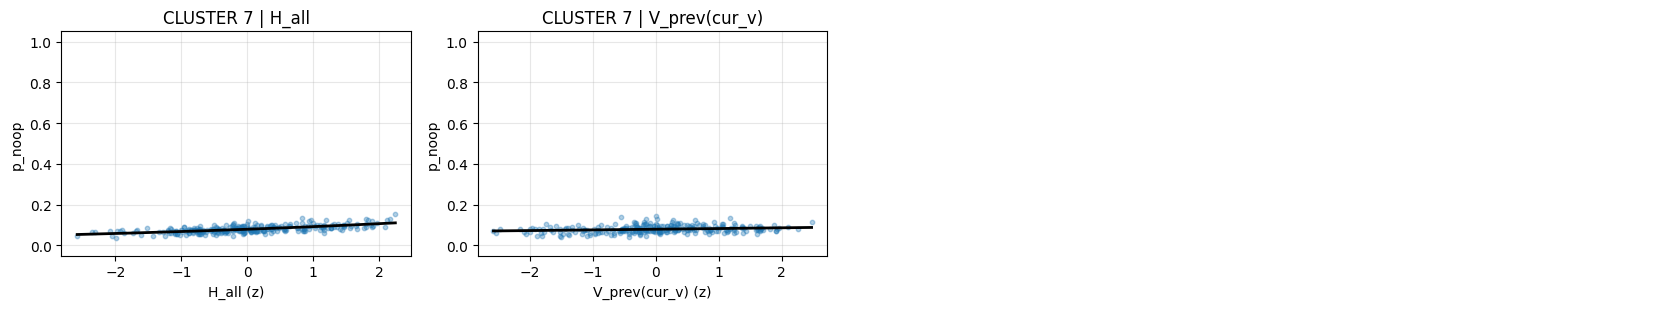


[CLUSTER 8] usable rows=1362 cols=6
                              BetaModel Results                               
Dep. Variable:                      y   Log-Likelihood:                 4013.7
Model:                      BetaModel   AIC:                            -8011.
Method:            Maximum Likelihood   BIC:                            -7970.
Date:                Mon, 09 Mar 2026                                         
Time:                        11:03:57                                         
No. Observations:                1362                                         
Df Residuals:                    1354                                         
Df Model:                           6                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -2.2938      0.004   -537.833      0.000      -2.302      -2.285
delta_

,coef,p
const,-2.293802,0.000000e+00
H_all,0.220194,0.000000e+00
V_prev(cur_v),0.052428,8.323952e-31
vre_abs_q,0.006368,1.216963e-01
vre_abs_v,-0.003382,4.312910e-01
delta_v,-0.001476,7.283865e-01
delta_q,0.000889,8.496460e-01


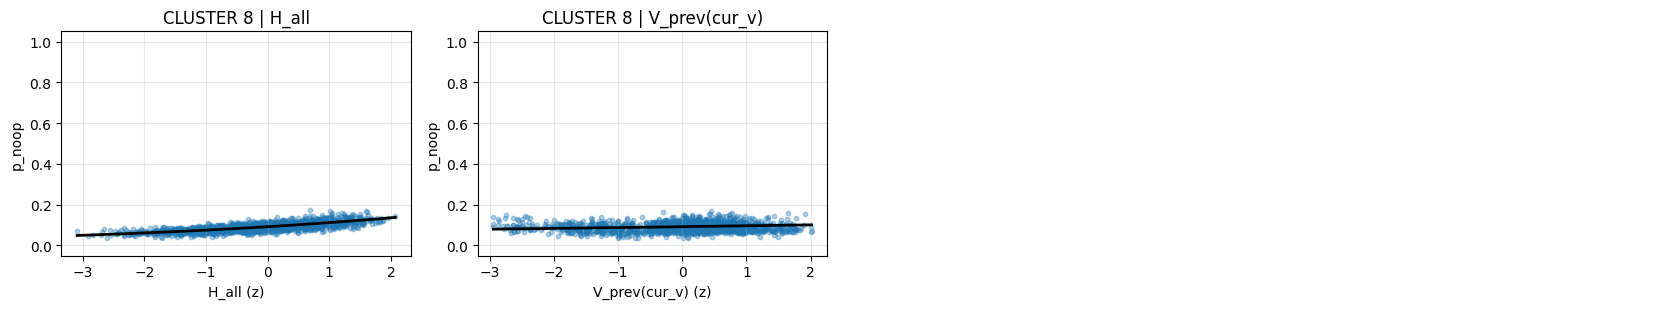


[CLUSTER 9] usable rows=297 cols=6
                              BetaModel Results                               
Dep. Variable:                      y   Log-Likelihood:                 891.39
Model:                      BetaModel   AIC:                            -1767.
Method:            Maximum Likelihood   BIC:                            -1737.
Date:                Mon, 09 Mar 2026                                         
Time:                        11:03:57                                         
No. Observations:                 297                                         
Df Residuals:                     289                                         
Df Model:                           6                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -2.4640      0.010   -250.514      0.000      -2.483      -2.445
delta_q

,coef,p
const,-2.463989,0.000000e+00
H_all,0.157850,1.050827e-51
V_prev(cur_v),0.035298,4.666006e-04
vre_abs_v,-0.010538,2.882798e-01
vre_abs_q,0.005284,5.832861e-01
delta_q,-0.005335,5.929854e-01
delta_v,0.002140,8.242603e-01


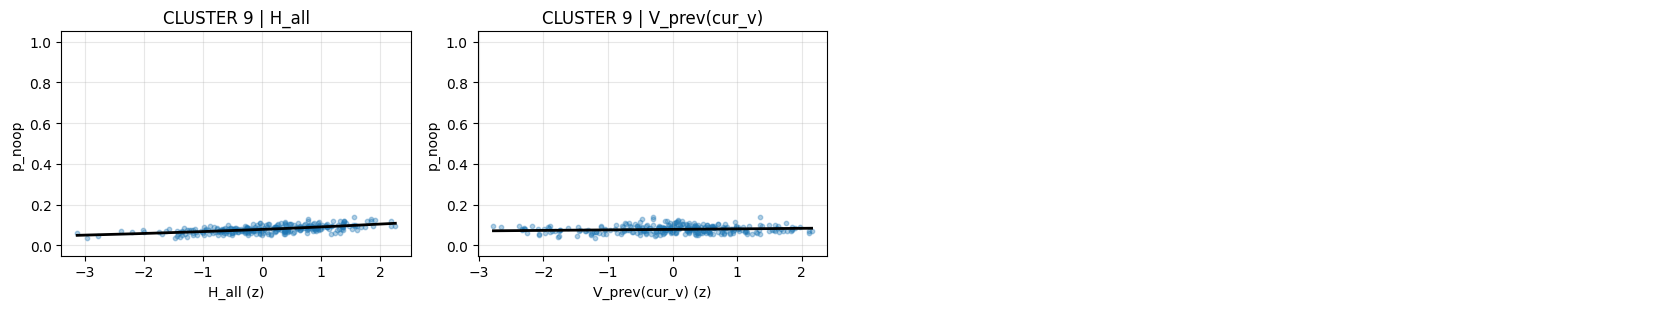


[CLUSTER 10] usable rows=350 cols=6
                              BetaModel Results                               
Dep. Variable:                      y   Log-Likelihood:                 1067.7
Model:                      BetaModel   AIC:                            -2119.
Method:            Maximum Likelihood   BIC:                            -2088.
Date:                Mon, 09 Mar 2026                                         
Time:                        11:03:58                                         
No. Observations:                 350                                         
Df Residuals:                     342                                         
Df Model:                           6                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -2.4705      0.009   -285.963      0.000      -2.487      -2.454
delta_

,coef,p
const,-2.470514,0.000000e+00
H_all,0.168011,9.926177e-90
V_prev(cur_v),0.018693,3.110276e-02
delta_q,0.008392,3.482296e-01
vre_abs_v,0.008049,3.508326e-01
delta_v,0.006748,4.188193e-01
vre_abs_q,-0.003310,6.992307e-01


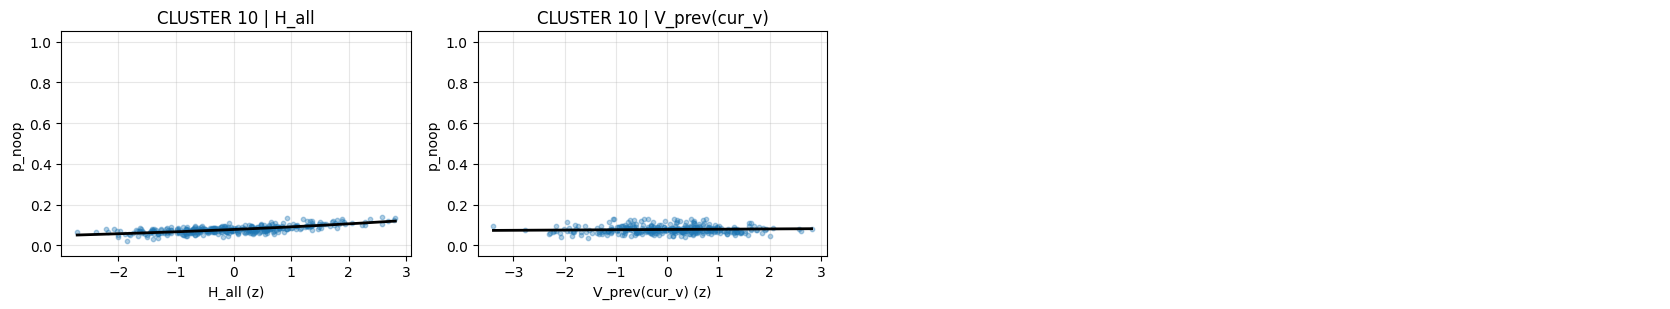


[CLUSTER 11] usable rows=183 cols=6
                              BetaModel Results                               
Dep. Variable:                      y   Log-Likelihood:                 537.66
Model:                      BetaModel   AIC:                            -1059.
Method:            Maximum Likelihood   BIC:                            -1034.
Date:                Mon, 09 Mar 2026                                         
Time:                        11:03:58                                         
No. Observations:                 183                                         
Df Residuals:                     175                                         
Df Model:                           6                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -2.2910      0.012   -198.469      0.000      -2.314      -2.268
delta_

,coef,p
const,-2.291036,0.000000e+00
H_all,0.218458,4.683440e-53
V_prev(cur_v),0.041019,1.278384e-03
delta_v,-0.016281,1.663919e-01
vre_abs_v,0.011542,3.316523e-01
vre_abs_q,0.004013,7.321703e-01
delta_q,-0.001922,8.804159e-01


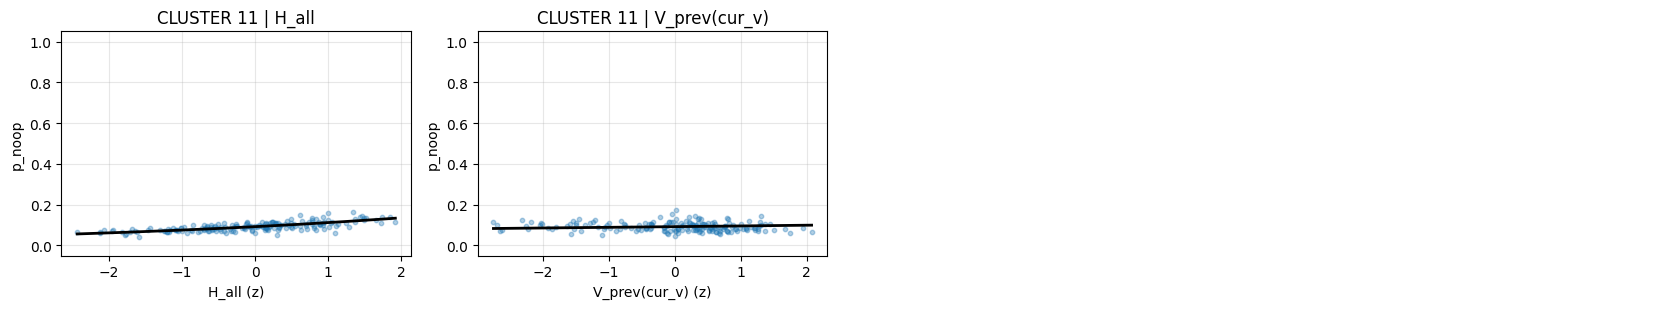


[CLUSTER 12] usable rows=67 cols=6
                              BetaModel Results                               
Dep. Variable:                      y   Log-Likelihood:                 214.77
Model:                      BetaModel   AIC:                            -413.5
Method:            Maximum Likelihood   BIC:                            -395.9
Date:                Mon, 09 Mar 2026                                         
Time:                        11:03:58                                         
No. Observations:                  67                                         
Df Residuals:                      59                                         
Df Model:                           6                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -2.4751      0.017   -144.155      0.000      -2.509      -2.441
delta_q

,coef,p
const,-2.475119,0.000000e+00
H_all,0.153910,1.388013e-13
V_prev(cur_v),0.068282,1.990977e-04
vre_abs_q,0.024556,1.602464e-01
vre_abs_v,-0.020351,2.553042e-01
delta_v,0.017354,3.033096e-01
delta_q,0.003857,8.312315e-01


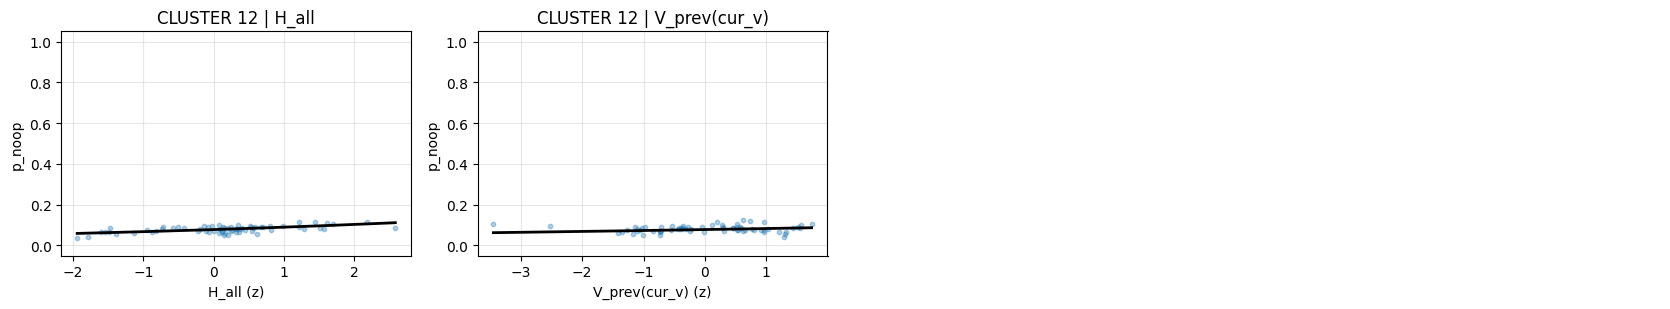


[CLUSTER 13] usable rows=213 cols=6
                              BetaModel Results                               
Dep. Variable:                      y   Log-Likelihood:                 631.55
Model:                      BetaModel   AIC:                            -1247.
Method:            Maximum Likelihood   BIC:                            -1220.
Date:                Mon, 09 Mar 2026                                         
Time:                        11:03:58                                         
No. Observations:                 213                                         
Df Residuals:                     205                                         
Df Model:                           6                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -2.2908      0.010   -219.479      0.000      -2.311      -2.270
delta_

,coef,p
const,-2.290783,0.000000e+00
H_all,0.239955,2.596822e-91
V_prev(cur_v),0.095467,3.133673e-15
vre_abs_q,0.018096,9.345079e-02
delta_q,-0.018067,1.041156e-01
delta_v,-0.016295,1.162562e-01
vre_abs_v,0.007224,4.933533e-01


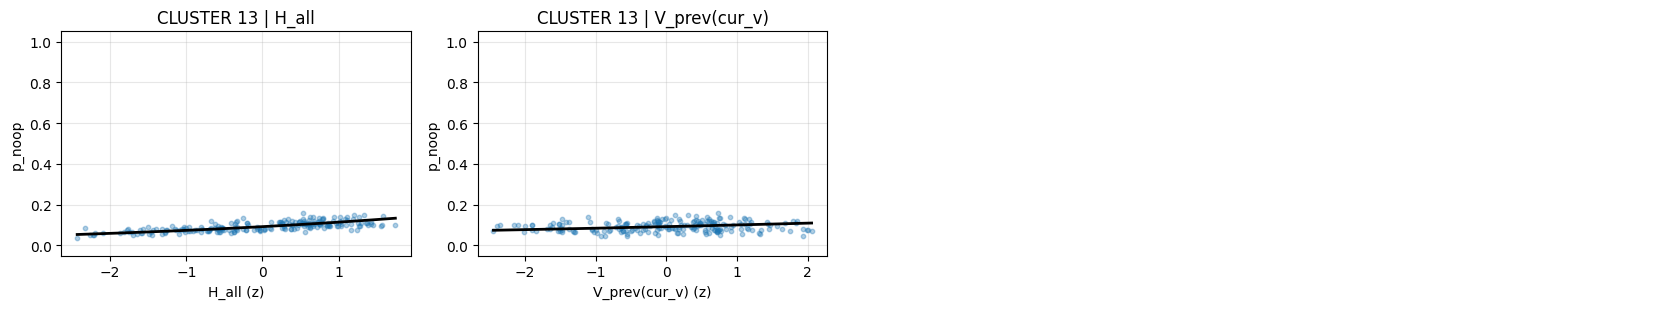


[CLUSTER 14] usable rows=44 cols=6
                              BetaModel Results                               
Dep. Variable:                      y   Log-Likelihood:                 136.61
Model:                      BetaModel   AIC:                            -257.2
Method:            Maximum Likelihood   BIC:                            -242.9
Date:                Mon, 09 Mar 2026                                         
Time:                        11:03:59                                         
No. Observations:                  44                                         
Df Residuals:                      36                                         
Df Model:                           6                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -2.3995      0.022   -109.933      0.000      -2.442      -2.357
delta_q

,coef,p
const,-2.399524,0.000000e+00
H_all,0.202625,8.272320e-19
V_prev(cur_v),0.065078,7.375806e-03
delta_q,-0.042258,9.997750e-02
vre_abs_v,-0.033662,1.914749e-01
vre_abs_q,-0.028282,2.289379e-01
delta_v,0.009227,6.782459e-01


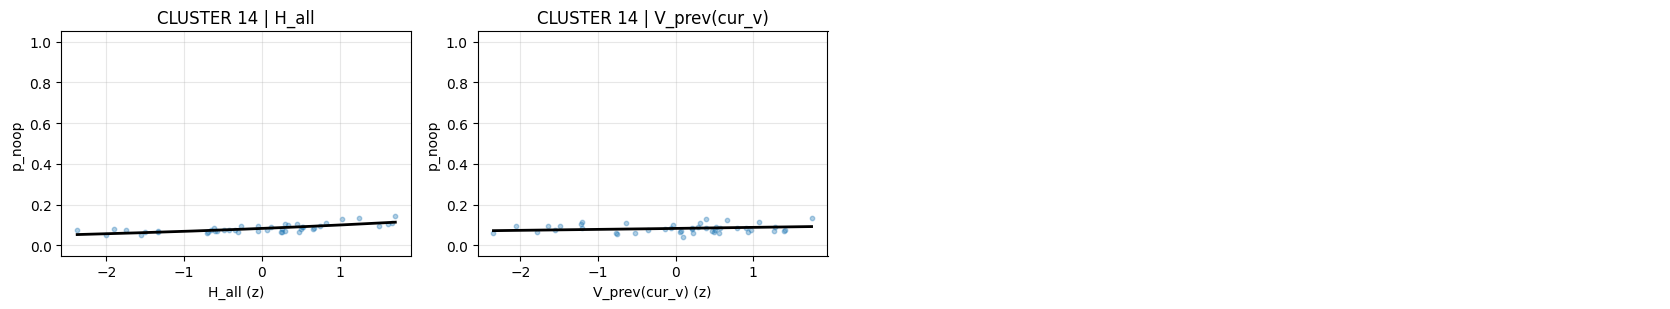


[CLUSTER 15] usable rows=200 cols=6
                              BetaModel Results                               
Dep. Variable:                      y   Log-Likelihood:                 603.63
Model:                      BetaModel   AIC:                            -1191.
Method:            Maximum Likelihood   BIC:                            -1165.
Date:                Mon, 09 Mar 2026                                         
Time:                        11:03:59                                         
No. Observations:                 200                                         
Df Residuals:                     192                                         
Df Model:                           6                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -2.4060      0.011   -211.008      0.000      -2.428      -2.384
delta_

,coef,p
const,-2.406013,0.000000e+00
H_all,0.240908,5.539857e-73
V_prev(cur_v),0.082939,1.785350e-10
vre_abs_q,-0.015385,1.961895e-01
vre_abs_v,-0.011874,3.166821e-01
delta_v,-0.009235,4.380572e-01
delta_q,0.003680,7.758325e-01


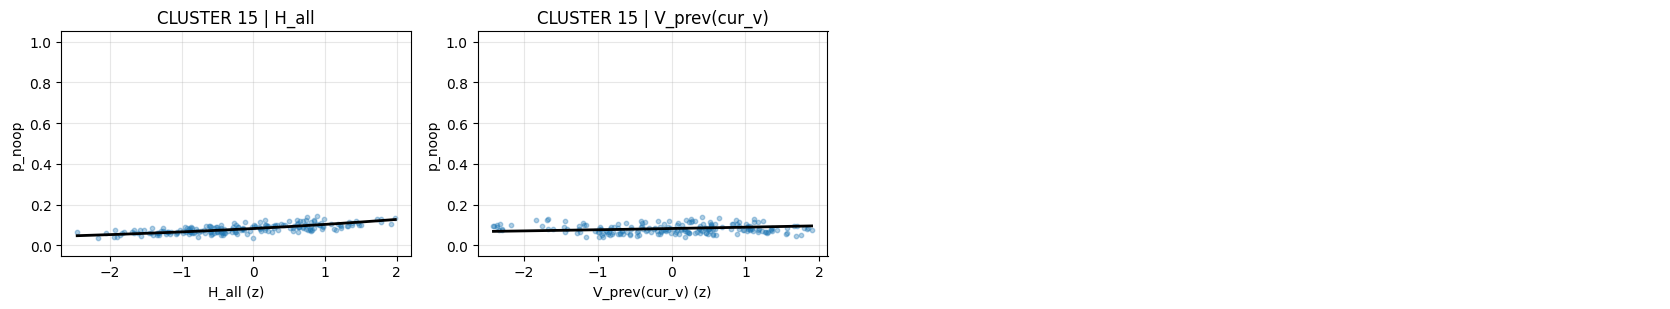


[CLUSTER 16] usable rows=40 cols=6
                              BetaModel Results                               
Dep. Variable:                      y   Log-Likelihood:                 97.517
Model:                      BetaModel   AIC:                            -179.0
Method:            Maximum Likelihood   BIC:                            -165.5
Date:                Mon, 09 Mar 2026                                         
Time:                        11:04:00                                         
No. Observations:                  40                                         
Df Residuals:                      32                                         
Df Model:                           6                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.8809      0.030    -62.806      0.000      -1.940      -1.822
delta_q

,coef,p
const,-1.880932,0.000000e+00
V_prev(cur_v),0.173994,4.558047e-07
H_all,0.131739,6.451062e-04
delta_v,-0.115776,3.025938e-03
vre_abs_v,0.050849,7.245297e-02
vre_abs_q,-0.054294,1.330990e-01
delta_q,-0.001363,9.616505e-01


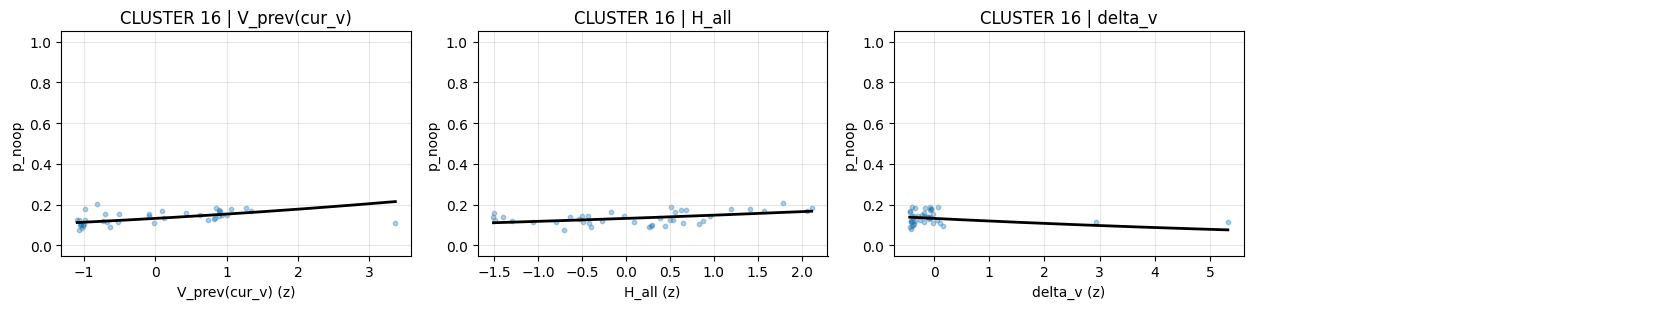


[CLUSTER 17] usable rows=40 cols=6
                              BetaModel Results                               
Dep. Variable:                      y   Log-Likelihood:                 94.787
Model:                      BetaModel   AIC:                            -173.6
Method:            Maximum Likelihood   BIC:                            -160.1
Date:                Mon, 09 Mar 2026                                         
Time:                        11:04:00                                         
No. Observations:                  40                                         
Df Residuals:                      32                                         
Df Model:                           6                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.9357      0.033    -58.837      0.000      -2.000      -1.871
delta_q

,coef,p
const,-1.935726,0.000000
V_prev(cur_v),0.087840,0.008227
H_all,0.111590,0.014833
delta_v,-0.175337,0.053897
vre_abs_v,0.210434,0.184801
delta_q,-0.138146,0.377093
vre_abs_q,-0.018548,0.702030


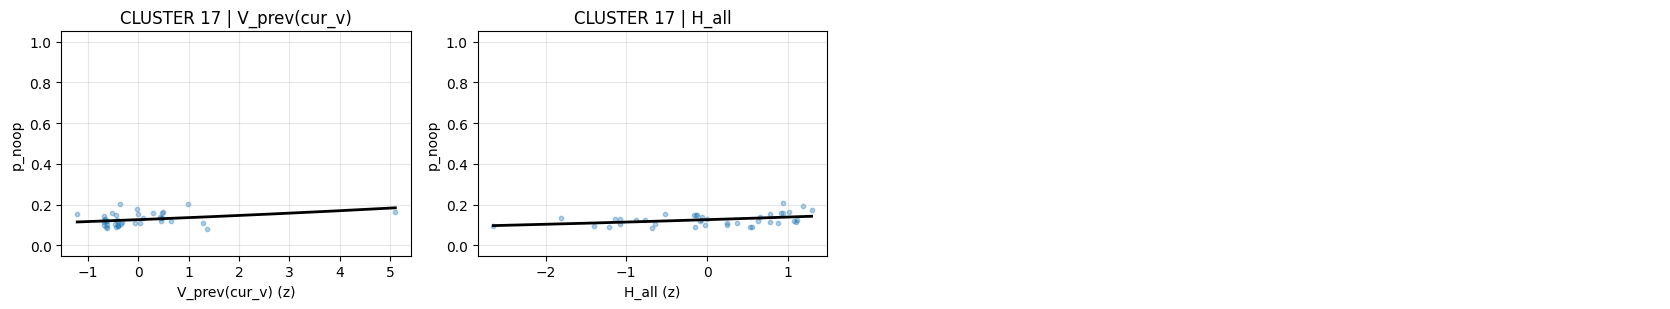


[CLUSTER 18] usable rows=66 cols=6
                              BetaModel Results                               
Dep. Variable:                      y   Log-Likelihood:                 161.73
Model:                      BetaModel   AIC:                            -307.5
Method:            Maximum Likelihood   BIC:                            -289.9
Date:                Mon, 09 Mar 2026                                         
Time:                        11:04:00                                         
No. Observations:                  66                                         
Df Residuals:                      58                                         
Df Model:                           6                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -2.0144      0.025    -80.374      0.000      -2.064      -1.965
delta_q

,coef,p
const,-2.014424,0.000000
H_all,0.083218,0.001209
vre_abs_v,-0.084843,0.012456
V_prev(cur_v),0.116583,0.027860
delta_q,-0.057113,0.322160
delta_v,-0.020235,0.554517
vre_abs_q,-0.006434,0.857658


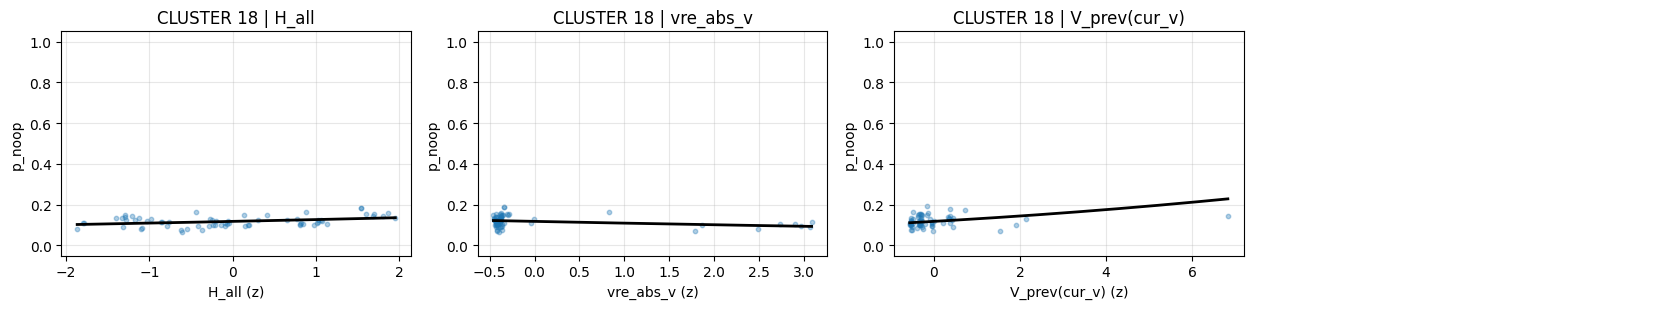


[CLUSTER 19] usable rows=71 cols=6
                              BetaModel Results                               
Dep. Variable:                      y   Log-Likelihood:                 169.65
Model:                      BetaModel   AIC:                            -323.3
Method:            Maximum Likelihood   BIC:                            -305.2
Date:                Mon, 09 Mar 2026                                         
Time:                        11:04:01                                         
No. Observations:                  71                                         
Df Residuals:                      63                                         
Df Model:                           6                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.9650      0.025    -77.822      0.000      -2.015      -1.916
delta_q

,coef,p
const,-1.965018,0.000000e+00
V_prev(cur_v),0.199956,4.713952e-10
H_all,0.160033,2.658573e-09
delta_v,-0.035169,1.963558e-01
delta_q,-0.008917,7.393475e-01
vre_abs_q,0.005098,8.378559e-01
vre_abs_v,0.001490,9.648831e-01


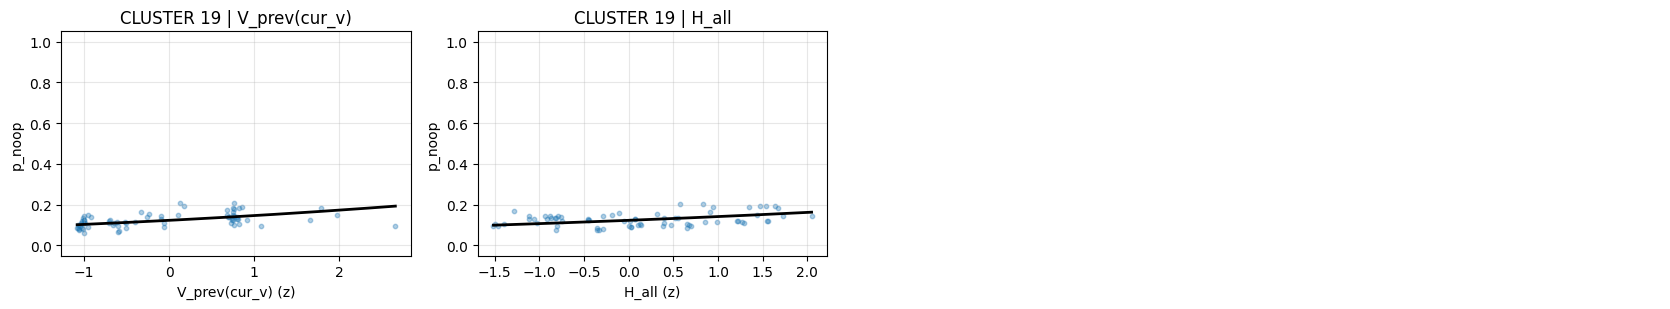


[CLUSTER 20] usable rows=78 cols=6
                              BetaModel Results                               
Dep. Variable:                      y   Log-Likelihood:                 172.92
Model:                      BetaModel   AIC:                            -329.8
Method:            Maximum Likelihood   BIC:                            -311.0
Date:                Mon, 09 Mar 2026                                         
Time:                        11:04:01                                         
No. Observations:                  78                                         
Df Residuals:                      70                                         
Df Model:                           6                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.9487      0.028    -69.896      0.000      -2.003      -1.894
delta_q

,coef,p
const,-1.948729,0.000000e+00
H_all,0.169723,2.847599e-07
delta_v,-0.104857,2.765378e-03
V_prev(cur_v),0.089086,4.566226e-03
vre_abs_v,0.085023,7.963857e-03
delta_q,0.096761,4.359107e-01
vre_abs_q,-0.068083,5.879069e-01


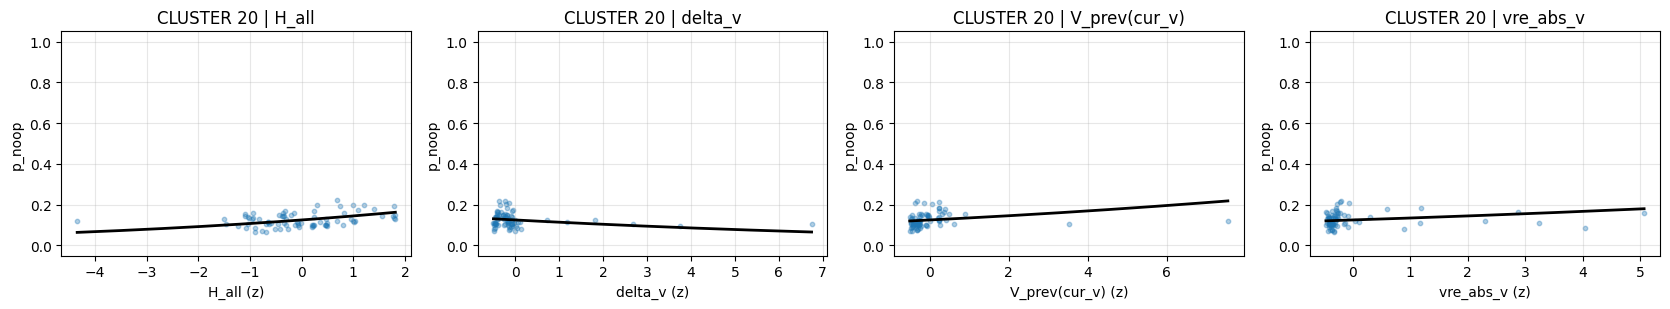


[CLUSTER 21] usable rows=17 cols=6
                              BetaModel Results                               
Dep. Variable:                      y   Log-Likelihood:                 57.354
Model:                      BetaModel   AIC:                            -98.71
Method:            Maximum Likelihood   BIC:                            -92.04
Date:                Mon, 09 Mar 2026                                         
Time:                        11:04:01                                         
No. Observations:                  17                                         
Df Residuals:                       9                                         
Df Model:                           6                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -2.2762      0.025    -89.325      0.000      -2.326      -2.226
delta_q

,coef,p
const,-2.276202,0.000000e+00
H_all,0.212633,1.470952e-13
vre_abs_v,0.095385,1.097843e-03
V_prev(cur_v),0.087680,5.617218e-03
delta_v,-0.036598,1.992060e-01
delta_q,0.020463,4.306958e-01
vre_abs_q,-0.014685,6.001078e-01


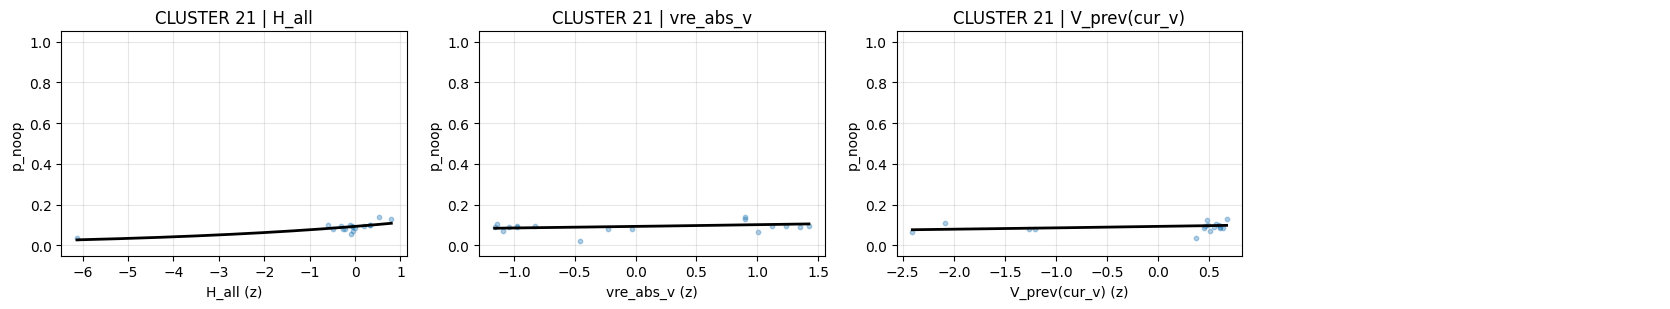


[CLUSTER 22] usable rows=33 cols=6
                              BetaModel Results                               
Dep. Variable:                      y   Log-Likelihood:                 83.597
Model:                      BetaModel   AIC:                            -151.2
Method:            Maximum Likelihood   BIC:                            -139.2
Date:                Mon, 09 Mar 2026                                         
Time:                        11:04:02                                         
No. Observations:                  33                                         
Df Residuals:                      25                                         
Df Model:                           6                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -2.0295      0.033    -61.031      0.000      -2.095      -1.964
delta_q

,coef,p
const,-2.029509,0.000000
H_all,0.169507,0.000270
V_prev(cur_v),0.246270,0.003573
vre_abs_v,0.124204,0.005664
delta_v,-0.229116,0.007656
delta_q,0.021087,0.574707
vre_abs_q,-0.010302,0.794737


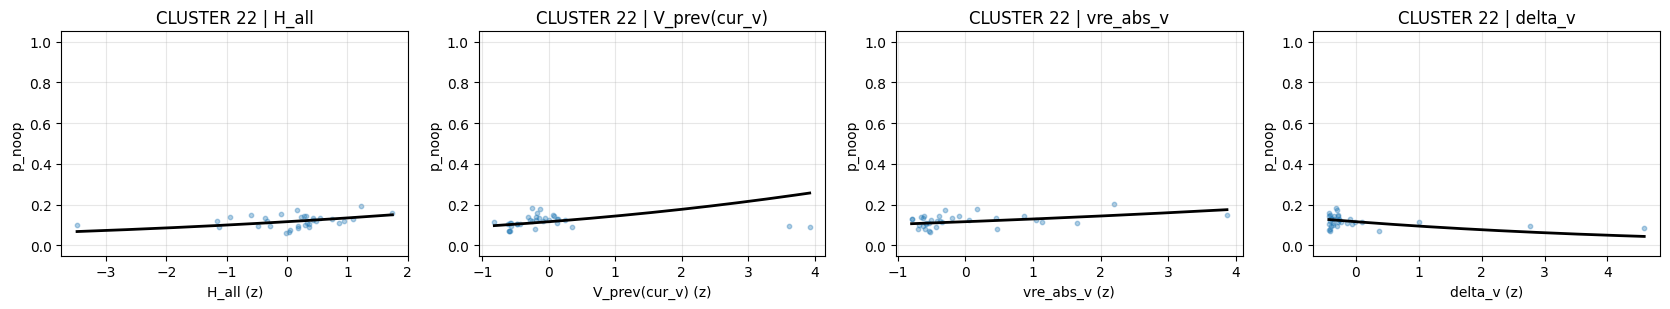

In [8]:
import re
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN

from openTSNE import TSNE as OpenTSNE, affinity, initialization

from IPython.display import display
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests

import statsmodels.api as sm
from statsmodels.othermod.betareg import BetaModel

# ====== 설정 ======
BASE_DIR = Path("./test")
FILE_GLOB = "*.npy"

FILTER_SUB = "sub001"
FILTER_SES = "04"
FILTER_BLOCK = None
FILTER_GAME = None
FILTER_SUFFIX = None

# None이면 전체 action 사용, 정수(예: 0)면 해당 action만 사용
ACTION_FILTER = None

RANDOM_STATE = 0
DELTA_V_STATUS = 2  # (하위 호환용 유지)
FRAGMENT_STATUSES = (1, 2)  # imagination fragment 분할에 사용할 status (전체 imagination)

# DBSCAN 설정 (openTSNE 좌표 기준)
DBSCAN_EPS = 5.5
DBSCAN_MIN_SAMPLES = 45
DBSCAN_METRIC = "euclidean"
INCLUDE_NOISE_IN_ANALYSIS = False  # True면 -1(noise)도 boxplot/beta 분석에 포함

# openTSNE 설정
TSNE_PERPLEXITY = 50
TSNE_PCA_DIM = 50
TSNE_AFFINITY_METHOD = "approx"
TSNE_METRIC = "euclidean"
TSNE_EARLY_EXAGGERATION_ITER = 250
TSNE_EARLY_EXAGGERATION = 12
TSNE_MAIN_ITER = 750
TSNE_REFINE_ITER = 250

# 박스플롯 유의성(별표) 설정
SIG_ALPHA = 0.05
SIG_CORRECTION = "fdr_bh"  # 'bonferroni', 'holm', 'fdr_bh' 등
SHOW_NS_IN_BOX = False
SHOW_GLOBAL_KRUSKAL_IN_TITLE = True
PRINT_PAIRWISE_P_TABLE = True

# tree_reps 키 목록
TREE_KEYS = [
    "root_action", "root_r", "root_d", "root_v", "root_policy",
    "root_qs_mean", "root_qs_max", "root_ns", "root_trail_r",
    "rollout_return", "max_rollout_return", "root_raw_action",
    "cur_action", "cur_r", "cur_d", "cur_v", "cur_policy",
    "cur_qs_mean", "cur_qs_max", "cur_ns", "cur_raw_action",
    "cur_reset", "k", "deprec", "action_seq",
]

# 베타 회귀 설명변수 (p_noop 제외)
REG_COLS = [
    "delta_q",
    "delta_v",
    "H_all",
    "V_prev(cur_v)",
    "vre_abs_q",
    "vre_abs_v",
]

# 박스플롯 비교 지표 (H_all 포함)
BOX_COLS = [
    "delta_q",
    "delta_v",
    "V_prev(cur_v)",
    "vre_abs_q",
    "vre_abs_v",
    "H_all",
    "p_noop",
]

# ====== 유틸 ======
def _clean(x):
    return None if x is None else str(x).strip()

FILTER_SUB = _clean(FILTER_SUB)
FILTER_SES = _clean(FILTER_SES)
FILTER_BLOCK = _clean(FILTER_BLOCK)
FILTER_GAME = _clean(FILTER_GAME)
FILTER_SUFFIX = _clean(FILTER_SUFFIX)


def parse_meta(path: Path):
    sub = path.parts[-3] if len(path.parts) >= 3 else None
    ses_folder = path.parts[-2] if len(path.parts) >= 2 else None

    base = path.stem

    def grab(pattern):
        m = re.search(pattern, base)
        return m.group(1) if m else None

    sub_in = grab(r"(sub\d+)")
    ses_in = grab(r"ses(\d+)")
    block_in = grab(r"block(\d+)")
    game_in = grab(r"game(\d+)")
    suffix_in = grab(r"_(\d+)$")

    if not sub_in and sub and re.match(r"sub\d+", sub):
        sub_in = sub
    if not ses_in and ses_folder and re.match(r"ses-\d+", ses_folder):
        ses_in = ses_folder.replace("ses-", "")

    return {
        "sub": sub_in,
        "ses": ses_in,
        "block": block_in,
        "game": game_in,
        "suffix": suffix_in,
        "file": str(path),
        "basename": path.name,
    }


def match_filter(val, flt):
    if flt is None:
        return True
    if val is None:
        return False
    return str(val).lstrip("0") == str(flt).lstrip("0")


def passes_filters(meta):
    return (
        (FILTER_SUB is None or meta["sub"] == FILTER_SUB)
        and match_filter(meta["ses"], FILTER_SES)
        and match_filter(meta["block"], FILTER_BLOCK)
        and match_filter(meta["game"], FILTER_GAME)
        and match_filter(meta["suffix"], FILTER_SUFFIX)
    )


def top2_gap(mat):
    if mat.shape[1] < 2:
        return np.full(mat.shape[0], np.nan)
    part = np.partition(mat, -2, axis=1)[:, -2:]
    return part.max(axis=1) - part.min(axis=1)


def top2_gap_1d(vals):
    if len(vals) < 2:
        return np.nan
    part = np.partition(vals, -2)[-2:]
    return part.max() - part.min()


def top2_gap_rowwise_ignore_nan(mat):
    out = np.full(mat.shape[0], np.nan, dtype=float)
    for i in range(mat.shape[0]):
        vals = mat[i, np.isfinite(mat[i])]
        if len(vals) >= 2:
            out[i] = top2_gap_1d(vals)
    return out


def to_action_ids(x):
    if x is None:
        return None
    arr = np.asarray(x)
    if arr.ndim == 1:
        return arr.astype(int)
    return np.argmax(arr, axis=1)


def prev_index_of_status(status_idx, ref_idx):
    if len(status_idx) == 0:
        return np.full(len(ref_idx), -1, dtype=int)
    pos = np.searchsorted(status_idx, ref_idx) - 1
    return np.where(pos >= 0, status_idx[pos], -1)


def as_numeric_1d(x):
    if x is None:
        return None
    arr = np.asarray(x)
    if arr.dtype == object:
        try:
            arr = arr.astype(float)
        except Exception:
            return None
    if not np.issubdtype(arr.dtype, np.number):
        return None
    return np.ravel(arr).astype(float)


def extract_tree_vec(tree, idx, keys):
    out = {}
    for k in keys:
        if k not in tree:
            out[k] = None
            continue
        arr = np.asarray(tree[k])
        if arr.ndim == 0:
            val = arr
        else:
            if idx >= arr.shape[0]:
                out[k] = None
                continue
            val = arr[idx]
        out[k] = as_numeric_1d(val)
    return out


def entropy_from_logits(logits_2d):
    if logits_2d is None:
        return None
    x = np.asarray(logits_2d, dtype=float)
    if x.ndim == 1:
        x = x.reshape(-1, 1)
    shift = x - np.max(x, axis=1, keepdims=True)
    p = np.exp(shift)
    denom = np.sum(p, axis=1, keepdims=True)
    denom = np.where(denom <= 0, 1.0, denom)
    p = p / denom
    return -np.nansum(p * np.log(p + 1e-12), axis=1), p


def split_contiguous(indices_1d: np.ndarray):
    if indices_1d.size == 0:
        return []
    cuts = np.where(np.diff(indices_1d) != 1)[0] + 1
    return np.split(indices_1d, cuts)


def cluster_label(cid):
    return "Noise" if cid == -1 else f"C{cid}"


def fit_tsne_opentsne(
    feature_matrix,
    perplexity=35,
    random_state=0,
    pca_dim=50,
    affinity_method="approx",
    metric="euclidean",
):
    n_samples = feature_matrix.shape[0]
    if n_samples < 3:
        raise RuntimeError("openTSNE 변환을 위해 최소 3개 샘플이 필요합니다.")

    scaler = StandardScaler()
    scaled = scaler.fit_transform(feature_matrix)

    pca_k = min(pca_dim, scaled.shape[1], n_samples - 1)
    if pca_k < 2:
        raise RuntimeError("PCA 차원을 만들 수 없습니다. 샘플 수/특징 수를 확인하세요.")

    reduced = PCA(n_components=pca_k, random_state=random_state).fit_transform(scaled)

    base = max(5, int(perplexity))
    base = min(base, n_samples - 1)

    perps = {base}
    perps.add(min(max(base * 5, base + 1), n_samples - 1))
    perps = sorted(p for p in perps if p >= 2 and p < n_samples)

    if len(perps) == 0:
        perps = [max(2, min(n_samples - 1, int(perplexity)))]
    perps = [25, 75]
    aff = affinity.Multiscale(
        reduced,
        perplexities=perps,
        method=affinity_method,
        metric=metric,
        n_jobs=-1,
        random_state=random_state,
    )
    init = initialization.pca(reduced, random_state=random_state)

    tsne = OpenTSNE(
        n_components=2,
        n_jobs=-1,
        negative_gradient_method="fft",
        early_exaggeration_iter=TSNE_EARLY_EXAGGERATION_ITER,
        early_exaggeration=TSNE_EARLY_EXAGGERATION,
        n_iter=TSNE_MAIN_ITER,
        random_state=random_state,
    )
    emb = tsne.fit(affinities=aff, initialization=init)

    if len(perps) > 1:
        aff.set_perplexities([float(min(perps))])
        emb = emb.optimize(n_iter=TSNE_REFINE_ITER, exaggeration=1, momentum=0.8)

    return np.asarray(emb), perps, pca_k


def build_df_real_steps(data):
    tree = data["tree_reps"]

    status = np.asarray(data["status"])
    q_all = np.asarray(tree["cur_qs_mean"])
    v_all = np.asarray(tree["cur_v"]).reshape(-1)
    root_qs = np.asarray(tree["root_qs_mean"]) if "root_qs_mean" in tree else None
    root_v_all = np.asarray(tree["root_v"]).reshape(-1) if "root_v" in tree else None

    actor_policy = np.asarray(data["actor_policy"]) if "actor_policy" in data else None
    if actor_policy is None:
        logits_all = None
    elif actor_policy.ndim >= 2:
        logits_all = actor_policy.reshape(actor_policy.shape[0], -1)
    else:
        logits_all = actor_policy.reshape(-1, 1)

    human_action_raw = data.get("human_action", None)
    human_action_ids = to_action_ids(human_action_raw)
    if human_action_raw is None:
        raise ValueError("human_action not found")

    if human_action_raw.ndim == 2:
        human_valid = human_action_raw.sum(axis=1) > 0
    else:
        human_valid = human_action_ids >= 0

    num_actions = q_all.shape[1]

    real_all = np.where(status == 0)[0]
    s2_indices = np.where(status == 2)[0]
    prev_s2_all = prev_index_of_status(s2_indices, real_all)

    s1_indices = np.where(status == 1)[0]
    prev_s1_all = prev_index_of_status(s1_indices, real_all)

    pos_all = np.arange(len(real_all))
    pos_in_real = pos_all[1:]
    real_indices = real_all[pos_in_real]

    prev_s2 = prev_s2_all[pos_in_real]
    prev_s1 = prev_s1_all[pos_in_real]

    valid = prev_s2 >= 0
    pos_in_real = pos_in_real[valid]
    real_indices = real_indices[valid]
    prev_s2 = prev_s2[valid]
    prev_s1 = prev_s1[valid]

    human_action_dec = human_action_ids[real_indices]
    valid_h = human_valid[real_indices]

    if "cur_action" in tree:
        cur_action = np.asarray(tree["cur_action"])
        if cur_action.ndim == 2 and cur_action.shape[1] == num_actions:
            cur_action_id = np.argmax(cur_action, axis=1)
        else:
            cur_action_id = cur_action.astype(int).reshape(-1)
    else:
        cur_action_id = None

    n_rows = len(pos_in_real)
    V_prev = np.full(n_rows, np.nan, dtype=float)
    Q_prev = np.full((n_rows, num_actions), np.nan, dtype=float)
    delta_v = np.full(n_rows, np.nan, dtype=float)
    vre_abs_v = np.full(n_rows, np.nan, dtype=float)

    for i, pos in enumerate(pos_in_real):
        if cur_action_id is None:
            continue

        curr_real_idx = real_indices[i]
        prev_real_idx = real_all[pos - 1]
        target_action = human_action_dec[i]

        if not (0 <= target_action < num_actions):
            continue

        between = np.arange(prev_real_idx + 1, curr_real_idx)
        if between.size == 0:
            continue

        imag_idx = between[np.isin(status[between], FRAGMENT_STATUSES)]
        if imag_idx.size == 0:
            continue

        frags = split_contiguous(imag_idx)

        matched_frags = []
        for frag in frags:
            if frag.size == 0:
                continue
            first_a = cur_action_id[frag[0]]
            if first_a == target_action:
                matched_frags.append(frag)

        if len(matched_frags) == 0:
            continue

        sel_idx = np.concatenate(matched_frags)

        V_prev[i] = np.mean(v_all[sel_idx])
        Q_prev[i, :] = np.mean(q_all[sel_idx, :], axis=0)

        action_means = []
        action_mean_map = {}
        for a in range(num_actions):
            mask_a = cur_action_id[sel_idx] == a
            if np.any(mask_a):
                mean_v = np.mean(v_all[sel_idx[mask_a]])
                action_means.append(mean_v)
                action_mean_map[a] = mean_v

        if len(action_means) >= 2:
            delta_v[i] = top2_gap_1d(np.array(action_means))

        if root_v_all is not None and curr_real_idx < len(root_v_all):
            if target_action in action_mean_map:
                vre_abs_v[i] = np.abs(action_mean_map[target_action] - root_v_all[curr_real_idx])

    delta_q = top2_gap_rowwise_ignore_nan(Q_prev)

    logits_prev = logits_all[prev_s2] if logits_all is not None else None
    if logits_prev is not None:
        H_all, pi_prev = entropy_from_logits(logits_prev)
        if pi_prev.shape[1] > 0:
            p_noop = pi_prev[:, 0]
        else:
            p_noop = np.full(n_rows, np.nan, dtype=float)
    else:
        H_all = np.full(n_rows, np.nan, dtype=float)
        p_noop = np.full(n_rows, np.nan, dtype=float)

    next_real = np.full(n_rows, -1, dtype=int)
    valid_next = (pos_in_real + 1) < len(real_all)
    next_real[valid_next] = real_all[pos_in_real[valid_next] + 1]

    vre = np.full(n_rows, np.nan, dtype=float)
    for i in range(n_rows):
        nr = next_real[i]
        if nr < 0:
            continue
        a = human_action_dec[i]
        if not (0 <= a < num_actions):
            continue
        if not np.isfinite(Q_prev[i, a]):
            continue

        if root_qs is not None and nr < root_qs.shape[0]:
            vre[i] = Q_prev[i, a] - root_qs[nr, a]
        elif nr < q_all.shape[0]:
            vre[i] = Q_prev[i, a] - q_all[nr, a]

    vre_abs_q = np.abs(vre)

    metrics = {
        "delta_q": delta_q,
        "delta_v": delta_v,
        "H_all": H_all,
        "p_noop": p_noop,
        "V_prev(cur_v)": V_prev,
        "vre": vre,
        "vre_abs_q": vre_abs_q,
        "vre_abs_v": vre_abs_v,
    }

    df = pd.DataFrame(metrics)
    return df, human_action_dec, valid_h, prev_s2


# ====== 박스플롯 유의성 유틸 ======
def p_to_stars(p):
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 5e-2:
        return "*"
    return "ns"


def safe_kruskal(groups):
    if len(groups) < 2:
        return np.nan
    try:
        return kruskal(*groups).pvalue
    except Exception:
        return np.nan


def pairwise_mwu_with_correction(groups, group_names, alpha=0.05, method="fdr_bh"):
    pairs = list(combinations(range(len(groups)), 2))
    raw_ps = []
    valid_pairs = []
    for i, j in pairs:
        x, y = groups[i], groups[j]
        if len(x) == 0 or len(y) == 0:
            continue
        try:
            p = mannwhitneyu(x, y, alternative="two-sided").pvalue
        except Exception:
            p = 1.0
        valid_pairs.append((i, j))
        raw_ps.append(p)

    if len(raw_ps) == 0:
        return []

    _, p_adj, _, _ = multipletests(raw_ps, alpha=alpha, method=method)
    results = []
    for (i, j), p_raw, p_corr in zip(valid_pairs, raw_ps, p_adj):
        results.append({
            "i": i,
            "j": j,
            "name_i": group_names[i],
            "name_j": group_names[j],
            "p_raw": float(p_raw),
            "p_adj": float(p_corr),
            "sig": bool(p_corr < alpha),
            "stars": p_to_stars(p_corr),
        })
    return results


def annotate_pairwise_stars(ax, groups, pairwise_results, show_ns=False):
    finite_groups = [g[np.isfinite(g)] for g in groups if len(g) > 0]
    if len(finite_groups) == 0:
        return
    y_max = max(np.max(g) for g in finite_groups)
    y_min = min(np.min(g) for g in finite_groups)
    y_range = y_max - y_min
    if not np.isfinite(y_range) or y_range <= 0:
        y_range = max(abs(y_max), 1.0)

    h = 0.03 * y_range
    step = 0.09 * y_range
    y = y_max + 0.06 * y_range

    draw_targets = [r for r in pairwise_results if r["sig"] or show_ns]
    draw_targets = sorted(draw_targets, key=lambda d: (d["j"] - d["i"], d["p_adj"]))

    for r in draw_targets:
        x1, x2 = r["i"] + 1, r["j"] + 1
        label = r["stars"] if r["sig"] else "ns"
        ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.0, c="k")
        ax.text((x1 + x2) / 2, y + h, label, ha="center", va="bottom", fontsize=10)
        y += step

    if len(draw_targets) > 0:
        ax.set_ylim(top=y + 0.05 * y_range)


# ====== beta regression ======
def plot_sig_beta(Xz_vif, y, params, sig_features, title_prefix=""):
    if len(sig_features) == 0:
        print(f"{title_prefix} no significant features")
        return

    rng = np.random.default_rng(0)
    n = len(sig_features)
    ncols = 4
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.2 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, feat in enumerate(sig_features):
        ax = axes[i]
        if feat not in Xz_vif.columns:
            ax.axis("off")
            continue
        x = Xz_vif[feat].values
        yj = y + (rng.random(len(y)) - 0.5) * 0.02
        ax.scatter(x, yj, s=10, alpha=0.35, c="tab:blue")

        x_grid = np.linspace(np.nanmin(x), np.nanmax(x), 200)
        b0 = params["const"] if "const" in params else 0.0
        b1 = params[feat] if feat in params else 0.0
        eta = b0 + b1 * x_grid
        mu = 1 / (1 + np.exp(-eta))
        ax.plot(x_grid, mu, color="black", lw=2)

        ax.set_ylim(-0.05, 1.05)
        ax.set_xlabel(f"{feat} (z)")
        ax.set_ylabel("p_noop")
        ax.set_title(f"{title_prefix}{feat}")
        ax.grid(alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


def run_p_noop_beta(df, title=""):
    if "p_noop" not in df.columns:
        print(f"[{title}] p_noop not found -> skip")
        return

    y = df["p_noop"].values
    X = df[[c for c in REG_COLS if c in df.columns]].copy()

    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.loc[:, ~X.isna().all()]
    X = X.loc[:, X.nunique(dropna=True) > 1]

    if X.shape[1] == 0:
        print(f"\n[{title}] usable rows=0 cols=0")
        print(" -> skip (no usable predictors)")
        return

    mean = X.mean()
    std = X.std(ddof=0)
    good_cols = std > 0
    X = X.loc[:, good_cols]
    Xz = (X - mean[good_cols]) / std[good_cols]

    mask = np.isfinite(Xz).all(axis=1) & np.isfinite(y)
    Xz = Xz[mask].reset_index(drop=True)
    y = y[mask]
    y = np.clip(y, 1e-4, 1 - 1e-4)

    print(f"\n[{title}] usable rows={len(y)} cols={Xz.shape[1]}")
    if len(y) == 0 or Xz.shape[1] == 0:
        print(" -> skip (no usable data)")
        return

    Xz_const = sm.add_constant(Xz, has_constant="add")
    try:
        res = BetaModel(y, Xz_const).fit(disp=False)
    except Exception as e:
        print("Beta regression failed:", e)
        return

    print(res.summary())
    k = Xz_const.shape[1]
    coef = pd.DataFrame({"coef": res.params[:k], "p": res.pvalues[:k]}, index=Xz_const.columns).sort_values("p")
    display(coef)

    sig = coef[(coef["p"] < 0.05) & (coef.index != "const")]
    sig_cols = [c for c in sig.index if c != "const"]
    plot_sig_beta(Xz, y, res.params, sig_cols, title_prefix=f"{title} | ")


# ====== 데이터 로드 ======
sub_dirs = [d for d in BASE_DIR.iterdir() if d.is_dir() and re.fullmatch(r"sub\d+", d.name)]

files = []
for sd in sub_dirs:
    files.extend(sd.rglob(FILE_GLOB))
files = sorted(files)
print(f"Found {len(files)} files under {BASE_DIR} (subXXX only)")

print("Discovered file list:")
if len(files) == 0:
    print(" - (none)")
else:
    for i, f in enumerate(files, 1):
        print(f" {i:02d}. {f}")

samples = []
filtered_files = []
used_files = []
used_file_sample_count = {}

for f in files:
    meta = parse_meta(f)
    if not passes_filters(meta):
        continue

    filtered_files.append(str(f))
    sample_count_before_file = len(samples)

    data = np.load(f, allow_pickle=True).item()
    df, human_action_dec, valid_h, prev_s2 = build_df_real_steps(data)

    df = df.loc[valid_h].reset_index(drop=True)
    human_action_dec = human_action_dec[valid_h]
    prev_s2 = prev_s2[valid_h]

    if ACTION_FILTER is not None:
        mask_action = (human_action_dec == ACTION_FILTER)
        df = df.loc[mask_action].reset_index(drop=True)
        human_action_dec = human_action_dec[mask_action]
        prev_s2 = prev_s2[mask_action]

    if len(df) == 0:
        continue

    tree = data["tree_reps"]

    for i in range(len(df)):
        tree_vec = extract_tree_vec(tree, prev_s2[i], TREE_KEYS)
        row = df.iloc[i].to_dict()
        row["human_action"] = int(human_action_dec[i])
        samples.append({"row": row, "tree_vec": tree_vec})

    added_count = len(samples) - sample_count_before_file
    if added_count > 0:
        used_files.append(str(f))
        used_file_sample_count[str(f)] = added_count

print(f"\nFiles passing filters (sub/ses/block/game/suffix): {len(filtered_files)}")
if len(filtered_files) == 0:
    print(" - (none)")
else:
    for i, fp in enumerate(filtered_files, 1):
        print(f" {i:02d}. {fp}")

print(f"\nFiles used for analysis: {len(used_files)}")
if len(used_files) == 0:
    print(" - (none)")
else:
    for i, fp in enumerate(used_files, 1):
        print(f" {i:02d}. {fp} (samples={used_file_sample_count[fp]})")

if len(samples) == 0:
    raise RuntimeError("분석 대상 샘플이 없습니다.")

# ====== tree_reps 키 중 일관된 것만 유지 ======
size_map = {k: set() for k in TREE_KEYS}
for s in samples:
    for k in TREE_KEYS:
        v = s["tree_vec"].get(k)
        if v is None:
            size_map[k].add(None)
        else:
            size_map[k].add(len(v))

keep_keys = [k for k, sizes in size_map.items() if (None not in sizes and len(sizes) == 1)]
drop_keys = [k for k in TREE_KEYS if k not in keep_keys]

print(f"Kept keys ({len(keep_keys)}): {keep_keys}")
print(f"Dropped keys ({len(drop_keys)}): {drop_keys}")

# ====== X + df_samples 구성 ======
X_rows, rows = [], []
for s in samples:
    vec = s["tree_vec"]
    if all(vec[k] is not None for k in keep_keys):
        X_rows.append(np.concatenate([vec[k] for k in keep_keys]))
        rows.append(s["row"])

if len(X_rows) == 0:
    raise RuntimeError("유효한 feature 벡터가 없습니다.")

X = np.vstack(X_rows)
df_samples = pd.DataFrame(rows)

if "human_action" in df_samples.columns:
    print("\nAction distribution in selected samples:")
    print(df_samples["human_action"].value_counts().sort_index())

# ====== openTSNE 변환 ======
X2, used_perps, used_pca_k = fit_tsne_opentsne(
    X,
    perplexity=TSNE_PERPLEXITY,
    random_state=RANDOM_STATE,
    pca_dim=TSNE_PCA_DIM,
    affinity_method=TSNE_AFFINITY_METHOD,
    metric=TSNE_METRIC,
)
print(
    f"openTSNE done: perplexities={used_perps}, pca_k={used_pca_k}, "
    f"n_samples={X.shape[0]}"
)

# ====== DBSCAN 클러스터링 (openTSNE 좌표 기준) ======
dbscan = DBSCAN(
    eps=DBSCAN_EPS,
    min_samples=DBSCAN_MIN_SAMPLES,
    metric=DBSCAN_METRIC,
)
labels = dbscan.fit_predict(X2)
df_samples["cluster"] = labels

unique_labels, counts = np.unique(labels, return_counts=True)
cluster_count_map = dict(zip(unique_labels.tolist(), counts.tolist()))
noise_count = cluster_count_map.get(-1, 0)
core_cluster_ids = sorted([cid for cid in unique_labels.tolist() if cid != -1])

print("Cluster counts (label -> n):", cluster_count_map)
print(f"Found clusters (excluding noise): {len(core_cluster_ids)}")
print(f"Noise samples (-1): {noise_count}")

if "human_action" in df_samples.columns:
    print("\nAction counts by cluster:")
    print(pd.crosstab(df_samples["cluster"], df_samples["human_action"]))

analysis_cluster_ids = core_cluster_ids.copy()
if INCLUDE_NOISE_IN_ANALYSIS and (-1 in unique_labels):
    analysis_cluster_ids = [-1] + analysis_cluster_ids

# H_all 유효 샘플 체크
if "H_all" in df_samples.columns:
    print(f"H_all finite rows: {np.isfinite(df_samples['H_all']).sum()} / {len(df_samples)}")

# ====== openTSNE 시각화 ======
cluster_ids_plot = sorted(np.unique(labels).tolist())
non_noise_ids = [cid for cid in cluster_ids_plot if cid != -1]

cmap = plt.get_cmap("rainbow", max(1, len(non_noise_ids)))
cluster_to_color = {}
for i, cid in enumerate(non_noise_ids):
    cluster_to_color[cid] = cmap(i)
cluster_to_color[-1] = (0.6, 0.6, 0.6, 0.8)  # noise는 회색

point_colors = [cluster_to_color.get(cid, (0, 0, 0, 1)) for cid in labels]

plt.figure(figsize=(7, 5))
plt.scatter(X2[:, 0], X2[:, 1], c=point_colors, s=10, alpha=0.75)
plt.title("Real-step Clusters (openTSNE 2D) - Raw tree_reps [DBSCAN]")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

# ====== 박스플롯: cluster별 요약 지표 + 유의성 별표 ======
use_cols = [c for c in BOX_COLS if c in df_samples.columns]
if len(use_cols) == 0:
    print("BOX_COLS 중 사용 가능한 컬럼이 없습니다.")
elif len(analysis_cluster_ids) == 0:
    print("분석 가능한 클러스터가 없습니다. (모든 샘플이 noise일 수 있음)")
else:
    n = len(use_cols)
    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5.0 * ncols, 3.8 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(use_cols):
        ax = axes[i]
        group_data, group_names = [], []

        for cid in analysis_cluster_ids:
            vals = df_samples.loc[df_samples["cluster"] == cid, col].values
            vals = vals[np.isfinite(vals)]
            if len(vals) > 0:
                group_data.append(vals)
                group_names.append(cluster_label(cid))

        if len(group_data) == 0:
            ax.axis("off")
            continue

        ax.boxplot(group_data, labels=group_names, showfliers=False)
        ax.grid(axis="y", alpha=0.3)

        global_p = safe_kruskal(group_data)
        if SHOW_GLOBAL_KRUSKAL_IN_TITLE and np.isfinite(global_p):
            ax.set_title(f"{col}\nKruskal p={global_p:.2e}")
        else:
            ax.set_title(col)

        pairwise_results = pairwise_mwu_with_correction(
            groups=group_data,
            group_names=group_names,
            alpha=SIG_ALPHA,
            method=SIG_CORRECTION,
        )

        annotate_pairwise_stars(
            ax=ax,
            groups=group_data,
            pairwise_results=pairwise_results,
            show_ns=SHOW_NS_IN_BOX,
        )

        if PRINT_PAIRWISE_P_TABLE:
            print(f"\n[{col}] pairwise MWU ({SIG_CORRECTION}, alpha={SIG_ALPHA})")
            if len(pairwise_results) == 0:
                print(" - no valid pairs")
            else:
                for r in pairwise_results:
                    print(
                        f" - {r['name_i']} vs {r['name_j']}: "
                        f"p_raw={r['p_raw']:.3e}, p_adj={r['p_adj']:.3e}, "
                        f"{'sig' if r['sig'] else 'ns'} {r['stars']}"
                    )

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

# ====== Cluster별 Beta Regression (p_noop) ======
if len(analysis_cluster_ids) == 0:
    print("Beta regression을 수행할 클러스터가 없습니다.")
else:
    for c in analysis_cluster_ids:
        df_c = df_samples.loc[df_samples["cluster"] == c].reset_index(drop=True)
        title = "NOISE" if c == -1 else f"CLUSTER {c}"
        run_p_noop_beta(df_c, title=title)


In [9]:
import numpy as np

def _logsumexp(x, axis=-1, keepdims=False):
    m = np.max(x, axis=axis, keepdims=True)
    y = m + np.log(np.sum(np.exp(x - m), axis=axis, keepdims=True))
    return y if keepdims else np.squeeze(y, axis=axis)

def _policy_logp_and_p(x):
    x = np.asarray(x)
    T, A = x.shape[0], x.shape[-1]
    if x.ndim == 2:
        maybe_prob = (x.min() >= 0) and (x.max() <= 1) and np.allclose(x.sum(axis=-1), 1.0, atol=1e-3)
        if maybe_prob:
            p = np.clip(x, 1e-12, 1.0)
            p = p / p.sum(axis=-1, keepdims=True)
            return np.log(p), p
        logp = x - _logsumexp(x, axis=-1, keepdims=True)
        return logp, np.exp(logp)
    D = int(np.prod(x.shape[1:-1]))
    x = x.reshape(T, D, A)
    maybe_prob = (x.min() >= 0) and (x.max() <= 1) and np.allclose(x.sum(axis=-1), 1.0, atol=1e-3)
    if maybe_prob:
        p = np.clip(x, 1e-12, 1.0)
        p = p / p.sum(axis=-1, keepdims=True)
    else:
        logp = x - _logsumexp(x, axis=-1, keepdims=True)
        p = np.exp(logp)
    p = p.mean(axis=1)
    p = p / p.sum(axis=-1, keepdims=True)
    return np.log(np.clip(p, 1e-12, 1.0)), p

def _to_action_and_valid(x):
    x = np.asarray(x)
    if x.ndim == 2:
        a = np.argmax(x, axis=1)
        v = x.sum(axis=1) > 0
        return a.astype(int), v
    a = x.astype(int)
    v = a >= 0
    return a, v

actor_policy = np.asarray(data["actor_policy"])
human_action, human_valid = _to_action_and_valid(data["human_action"])
thinker_action, thinker_valid = _to_action_and_valid(data["thinker_action"])

T = min(actor_policy.shape[0], len(human_action), len(thinker_action))
actor_policy = actor_policy[:T]
human_action = human_action[:T]
thinker_action = thinker_action[:T]
human_valid = human_valid[:T]
thinker_valid = thinker_valid[:T]

logp, probs = _policy_logp_and_p(actor_policy)
A = probs.shape[1]

valid_action_h = (human_action >= 0) & (human_action < A)
valid_action_m = (thinker_action >= 0) & (thinker_action < A)

mask = human_valid & thinker_valid & valid_action_h & valid_action_m
if "status" in data:
    status = np.asarray(data["status"])[:T]
    mask = mask & (status == 0)

idx = np.where(mask)[0]
assert len(idx) > 0

agree_tm = (thinker_action[idx] == human_action[idx]).mean()
argmax_acc = (np.argmax(probs[idx], axis=1) == human_action[idx]).mean()

ll_h = logp[idx, human_action[idx]]
nll_h = -ll_h
ppl_h = float(np.exp(nll_h.mean()))
ea_h = float(probs[idx, human_action[idx]].mean())

ll_m = logp[idx, thinker_action[idx]]
nll_m = -ll_m
ppl_m = float(np.exp(nll_m.mean()))
ea_m = float(probs[idx, thinker_action[idx]].mean())

nll_uniform = float(np.log(A))
ppl_uniform = float(A)
delta_nll_vs_uniform = float(nll_uniform - nll_h.mean())

print("N samples:", len(idx))
print("A (action space):", A)
print("thinker-human agreement:", float(agree_tm))
print("policy argmax-human accuracy:", float(argmax_acc))

print("human mean log-likelihood:", float(ll_h.mean()))
print("human mean NLL:", float(nll_h.mean()))
print("human perplexity:", ppl_h)
print("human expected agreement (E[pi(a_h)]):", ea_h)

print("thinker mean log-likelihood:", float(ll_m.mean()))
print("thinker mean NLL:", float(nll_m.mean()))
print("thinker perplexity:", ppl_m)
print("thinker expected agreement (E[pi(a_m)]):", ea_m)

print("uniform mean NLL (=log A):", nll_uniform)
print("uniform perplexity (=A):", ppl_uniform)
print("delta NLL vs uniform (log A - NLL_h):", delta_nll_vs_uniform)


N samples: 5796
A (action space): 6
thinker-human agreement: 0.27553485162180813
policy argmax-human accuracy: 0.31590752242926157
human mean log-likelihood: -1.5016924142837524
human mean NLL: 1.5016924142837524
human perplexity: 4.4892802238464355
human expected agreement (E[pi(a_h)]): 0.2553431987762451
thinker mean log-likelihood: -1.4711021184921265
thinker mean NLL: 1.4711021184921265
thinker perplexity: 4.354031085968018
thinker expected agreement (E[pi(a_m)]): 0.274883508682251
uniform mean NLL (=log A): 1.791759469228055
uniform perplexity (=A): 6.0
delta NLL vs uniform (log A - NLL_h): 0.2900670549443025
